# Strategy Analysis Notebook

**Purpose:** Validate the mean-reversion hypothesis — does the strategy have tradeable edge, and under what conditions?

**Input:** `clean.csv` — produced by `preparing.ipynb`. One row per intraday bar, multiple bars per trading day.

**Two DataFrames used throughout:**
- `df` — all bars (used for time-of-day analysis)
- `df_day` — one row per trading day (used for win rate, VIX filter, and most other analyses)

Run cells top-to-bottom. Requires `clean.csv` in the same directory.

---
## Section 0: Setup & Data Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import binomtest

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# ── Color convention (used on every win-rate chart) ──────────────────────────
def win_rate_color(rate):
    """Green >55%, yellow 50-55%, red <50%."""
    if rate > 0.55:
        return '#2ecc71'
    elif rate >= 0.50:
        return '#f1c40f'
    else:
        return '#e74c3c'

def bar_colors(rates):
    return [win_rate_color(r) for r in rates]

def add_50pct_line(ax):
    ax.axhline(0.50, color='black', linestyle='--', linewidth=1, label='50% baseline')

def fmt_pct(ax):
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))


def annotate_heatmap(rate_df, count_df, flag_threshold=None):
    """Build annotated cell strings for seaborn heatmaps.
    Adds N count below each percentage; flags cells with count < flag_threshold with *.
    """
    annot = rate_df.copy().astype(object)
    for r in rate_df.index:
        for c in rate_df.columns:
            val = rate_df.loc[r, c]
            n_val = count_df.loc[r, c]
            if pd.isna(val):
                annot.loc[r, c] = ''
            else:
                flag = '*' if flag_threshold and n_val < flag_threshold else ''
                annot.loc[r, c] = f'{val:.0%}{flag}\n({n_val:.0f})'
    return annot

print('Libraries loaded.')

Libraries loaded.


In [2]:
# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv('clean.csv', parse_dates=['date'])

# Normalize string columns
df['money_made']        = df['money_made'].str.strip().str.lower()
df['philo_result']      = df['philo_result'].str.strip().str.lower()
df['initial_direction'] = df['initial_direction'].str.strip().str.lower()

# vix_favorable may have been saved as string 'True'/'False'
if df['vix_favorable'].dtype == object:
    df['vix_favorable'] = df['vix_favorable'].map({'True': True, 'False': False})

# ── Day-level DataFrame (one row per trading day) ─────────────────────────────
# Day-level columns are identical for every bar within a day; take first row.
DAY_COLS = [
    'date', 'day_of_week', 'year', 'month',
    'market_open_09:30', 'initial_direction',
    'contract_location', 'above', 'below',
    'market_close_16:15', 'market_reg_close_16:00',
    'day_direction_16:15', 'day_direction_reg_16:00',
    'philo_result', 'money_made',
    'diff_open_close', 'rounded_diff_open_close',
    'open_close_diff_sdv_interval', 'open_close_diff_nearest_sdv',
    'diff_open_conLoc', 'open_conLoc_diff_sdv_interval', 'open_conLoc_diff_nearest_sdv',
    'dow_win_streak', 'dow_loss_streak',
    'overall_win_streak', 'overall_loss_streak',
    'vix_close', 'vix_category', 'vix_favorable',
]
df_day = df[DAY_COLS].groupby('date', as_index=False).first()

# ── Sanity check ─────────────────────────────────────────────────────────────
print(f'Bars loaded      : {len(df):,}')
print(f'Unique days      : {len(df_day):,}')
print(f'Date range       : {df_day["date"].min().date()} → {df_day["date"].max().date()}')
print(f'Avg bars/day     : {len(df) / len(df_day):.1f}')
print()

# Missing values across key columns
key_cols = ['money_made', 'philo_result', 'vix_close', 'vix_favorable',
            'contract_location', 'diff_open_close', 'open_close_diff_sdv_interval']
missing = df_day[key_cols].isna().sum()
if missing.any():
    print('Missing values in day-level data:')
    print(missing[missing > 0])
else:
    print('No missing values in key columns.')

df_day.head(3)

Bars loaded      : 35,164
Unique days      : 533
Date range       : 2024-03-11 → 2026-04-09
Avg bars/day     : 66.0

Missing values in day-level data:
contract_location               26
diff_open_close                 25
open_close_diff_sdv_interval    25
dtype: int64


,date,day_of_week,year,month,market_open_09:30,initial_direction,contract_location,above,below,market_close_16:15,...,diff_open_conLoc,open_conLoc_diff_sdv_interval,open_conLoc_diff_nearest_sdv,dow_win_streak,dow_loss_streak,overall_win_streak,overall_loss_streak,vix_close,vix_category,vix_favorable
0,2024-03-11,Monday,2024,3,5177.75,above,5169.0,5181.0,5169.0,5188.00,...,8.75,Slightly High,0.0,0,1,0,1,15.22,Moderate,True
1,2024-03-12,Tuesday,2024,3,5177.75,above,5203.0,5215.0,5203.0,5241.75,...,25.25,Extremely High,4.0,0,1,0,1,13.84,Low,False
2,2024-03-13,Wednesday,2024,3,5206.25,above,5239.0,5251.0,5239.0,5236.00,...,32.75,Extremely High,5.0,1,0,2,0,13.75,Low,False


---
## Section 1: Dataset Overview

Before trusting any win rate, confirm the dataset is complete and balanced across years. A suspiciously sparse year (data gap) or an unbalanced dataset could skew all downstream results.

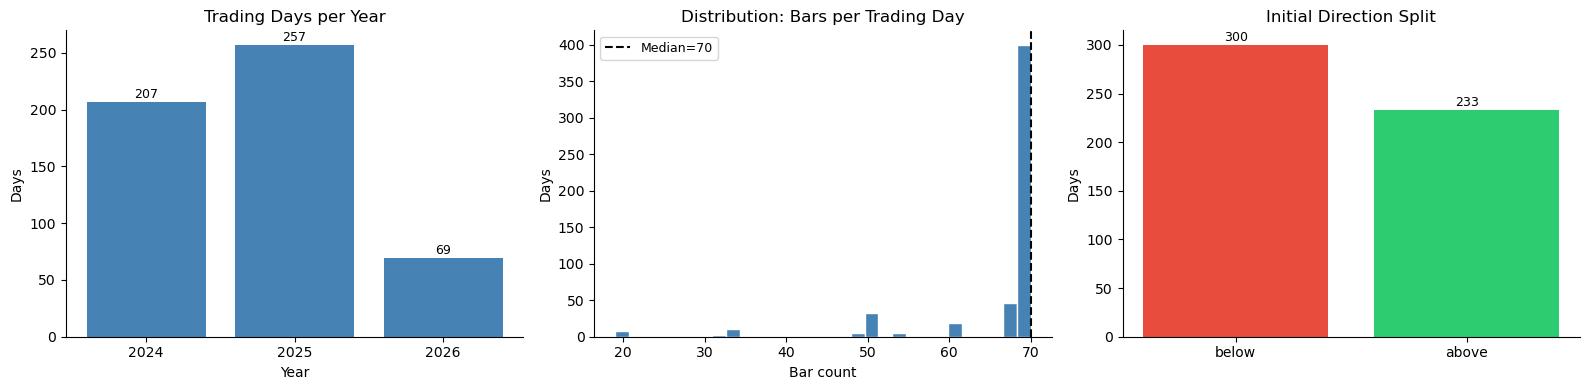


VIX category distribution (days):
              count   pct
vix_category             
Moderate        369  69.2
Low             126  23.6
Elevated         32   6.0
High              6   1.1


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Trading days per year
days_per_year = df_day.groupby('year').size()
axes[0].bar(days_per_year.index.astype(str), days_per_year.values, color='steelblue')
for i, (yr, n) in enumerate(days_per_year.items()):
    axes[0].text(i, n + 1, str(n), ha='center', va='bottom', fontsize=9)
axes[0].set_title('Trading Days per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Days')

# Bars per day distribution
bars_per_day = df.groupby('date').size()
axes[1].hist(bars_per_day.values, bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Distribution: Bars per Trading Day')
axes[1].set_xlabel('Bar count')
axes[1].set_ylabel('Days')
axes[1].axvline(bars_per_day.median(), color='black', linestyle='--', label=f'Median={bars_per_day.median():.0f}')
axes[1].legend(fontsize=9)

# Initial direction split
dir_counts = df_day['initial_direction'].value_counts()
axes[2].bar(dir_counts.index, dir_counts.values, color=['#e74c3c', '#2ecc71', '#95a5a6'])
for i, (lbl, n) in enumerate(dir_counts.items()):
    axes[2].text(i, n + 1, str(n), ha='center', va='bottom', fontsize=9)
axes[2].set_title('Initial Direction Split')
axes[2].set_ylabel('Days')

plt.tight_layout()
plt.show()

# VIX category distribution
print('\nVIX category distribution (days):')
print(df_day['vix_category'].value_counts().to_frame('count').assign(
    pct=lambda x: (x['count'] / x['count'].sum() * 100).round(1)
))

*Interpretation: note any years with significantly fewer days (possible data gaps), and whether above/below days are roughly balanced. An imbalanced direction split could indicate a systematic bias in the data.*

---
## Section 2: Core Hypothesis — Overall Win Rate ⭐

The fundamental question: does the mean-reversion strategy win more than 50% of the time?

We track two metrics:
- **`philo_result`** — did the reversal actually happen? (direction-only)
- **`money_made`** — did price cross the contract strike? (the tradeable outcome)

The gap between them reveals the cost of the strike placement.

In [4]:
df_core = df_day.dropna(subset=['money_made', 'philo_result'])
n = len(df_core)

philo_wins  = (df_core['philo_result'] == 'correct').sum()
money_wins  = (df_core['money_made']   == 'yes').sum()
philo_rate  = philo_wins / n
money_rate  = money_wins / n

# Binomial tests vs. p=0.50
philo_test = binomtest(philo_wins, n, p=0.5, alternative='greater')
money_test = binomtest(money_wins, n, p=0.5, alternative='greater')

# 95% Clopper-Pearson confidence intervals
philo_ci = philo_test.proportion_ci(confidence_level=0.95)
money_ci = money_test.proportion_ci(confidence_level=0.95)

print('=' * 58)
print(f'  N = {n:,} trading days')
print('=' * 58)
print(f'  Philosophical win rate  : {philo_rate:.1%}  (p={philo_test.pvalue:.4f})')
print(f'    95% CI: [{philo_ci.low:.1%}, {philo_ci.high:.1%}]')
print()
print(f'  Tradeable win rate      : {money_rate:.1%}  (p={money_test.pvalue:.4f})')
print(f'    95% CI: [{money_ci.low:.1%}, {money_ci.high:.1%}]')
print()
print(f'  Strike cost (gap)       : {philo_rate - money_rate:.1%}')
print('=' * 58)
print()

if money_test.pvalue < 0.05:
    print('  RESULT: Tradeable win rate is statistically significant (p < 0.05). Strategy shows edge.')
elif money_test.pvalue < 0.10:
    print('  RESULT: Marginal significance (0.05 < p < 0.10). More data needed for confidence.')
else:
    print('  RESULT: Not statistically significant (p >= 0.10). Cannot reject null hypothesis.')

  N = 533 trading days
  Philosophical win rate  : 41.8%  (p=0.9999)
    95% CI: [38.3%, 100.0%]

  Tradeable win rate      : 37.0%  (p=1.0000)
    95% CI: [33.5%, 100.0%]

  Strike cost (gap)       : 4.9%

  RESULT: Not statistically significant (p >= 0.10). Cannot reject null hypothesis.


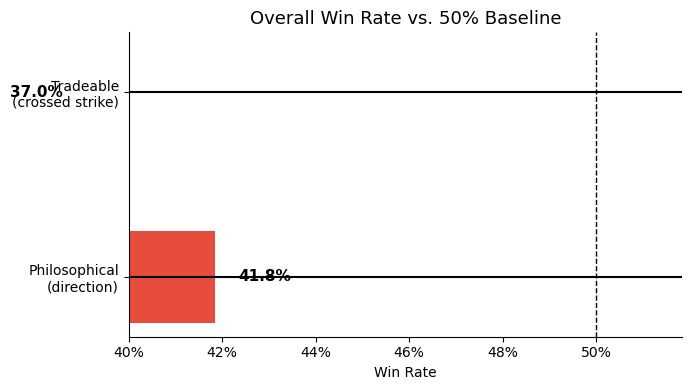

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))

labels = ['Philosophical\n(direction)', 'Tradeable\n(crossed strike)']
rates  = [philo_rate, money_rate]
xerr_lo = [philo_rate - philo_ci.low,  money_rate - money_ci.low]
xerr_hi = [philo_ci.high - philo_rate, money_ci.high - money_rate]

bars = ax.barh(labels, rates, color=bar_colors(rates), height=0.5)
ax.errorbar(rates, labels, xerr=[xerr_lo, xerr_hi],
            fmt='none', color='black', capsize=5, linewidth=1.5)
ax.axvline(0.50, color='black', linestyle='--', linewidth=1)
for bar, rate in zip(bars, rates):
    ax.text(rate + 0.005, bar.get_y() + bar.get_height()/2,
            f'{rate:.1%}', va='center', fontsize=11, fontweight='bold')
ax.set_xlim(0.40, min(max(rates) + 0.10, 1.0))
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_title('Overall Win Rate vs. 50% Baseline', fontsize=13)
ax.set_xlabel('Win Rate')
plt.tight_layout()
plt.show()

---
## Section 3: VIX Filter Validation ⭐

Does restricting trades to days where VIX is 15–30 (`vix_favorable == True`) improve win rate? This was the key question from the VIX integration work. We also need to know: how often does this filter apply — if it covers only 10% of days, it may not be worth using.

VIX categories: Low (<15) · Moderate (15–25) · Elevated (25–35) · High (>35). `vix_favorable` covers Moderate + the lower part of Elevated (VIX 15–30).

In [6]:
# ── Favorable vs. unfavorable ─────────────────────────────────────────────────
fav   = df_day[df_day['vix_favorable'] == True]
unfav = df_day[df_day['vix_favorable'] == False]

def win_rate_stats(subset, label):
    n_s = len(subset.dropna(subset=['money_made']))
    wins = (subset['money_made'] == 'yes').sum()
    rate = wins / n_s if n_s > 0 else np.nan
    pct_of_total = n_s / len(df_day) * 100
    return {'Label': label, 'N days': n_s, '% of total': f'{pct_of_total:.1f}%', 'Win rate': f'{rate:.1%}'}

summary = pd.DataFrame([
    win_rate_stats(df_day, 'All days'),
    win_rate_stats(fav,    'VIX favorable (15–30)'),
    win_rate_stats(unfav,  'VIX unfavorable'),
])
print(summary.to_string(index=False))

                Label  N days % of total Win rate
             All days     533     100.0%    37.0%
VIX favorable (15–30)     392      73.5%    38.0%
      VIX unfavorable     141      26.5%    34.0%


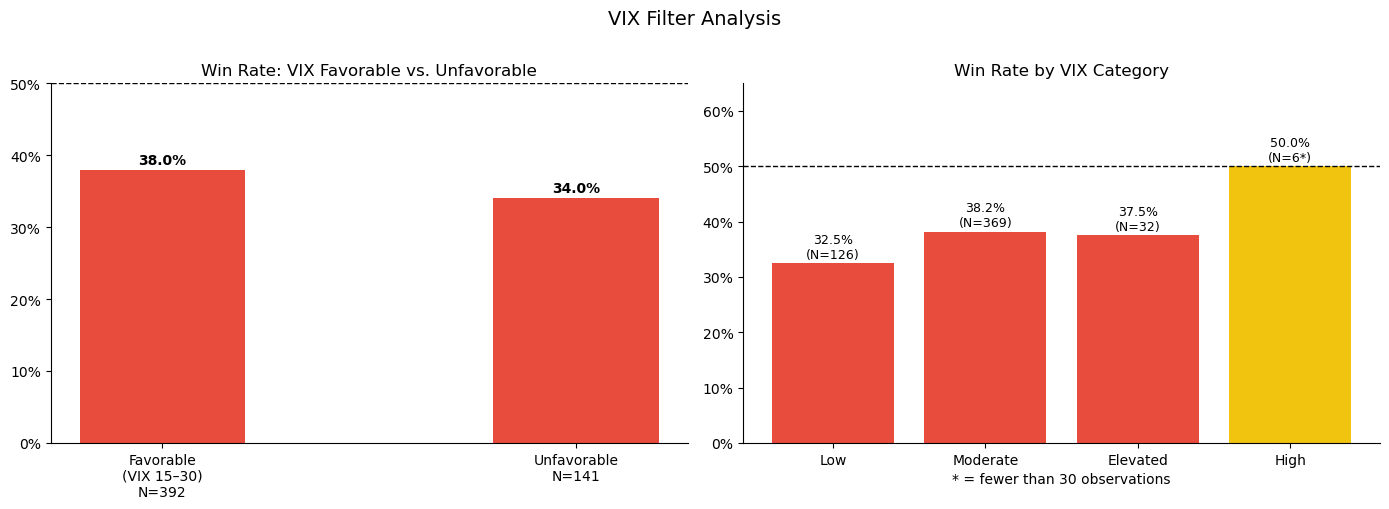

In [7]:
# ── Win rate by VIX category ──────────────────────────────────────────────────
cat_order = ['Low', 'Moderate', 'Elevated', 'High']
vix_stats = (
    df_day.dropna(subset=['money_made', 'vix_category'])
    .groupby('vix_category')
    .agg(n=('money_made', 'count'),
         wins=('money_made', lambda x: (x == 'yes').sum()))
    .assign(win_rate=lambda x: x['wins'] / x['n'])
    .reindex([c for c in cat_order if c in df_day['vix_category'].unique()])
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: favorable vs unfavorable
fav_rates  = [(fav['money_made'] == 'yes').mean(), (unfav['money_made'] == 'yes').mean()]
fav_labels = [f'Favorable\n(VIX 15–30)\nN={len(fav)}', f'Unfavorable\nN={len(unfav)}']
bars_l = axes[0].bar(fav_labels, fav_rates, color=bar_colors(fav_rates), width=0.4)
add_50pct_line(axes[0])
fmt_pct(axes[0])
for bar, rate in zip(bars_l, fav_rates):
    axes[0].text(bar.get_x() + bar.get_width()/2, rate + 0.004,
                 f'{rate:.1%}', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Win Rate: VIX Favorable vs. Unfavorable')
axes[0].set_ylim(0, max(fav_rates) + 0.12)

# Right: by VIX category
cats  = vix_stats.index.tolist()
rates = vix_stats['win_rate'].tolist()
ns    = vix_stats['n'].tolist()
bars_r = axes[1].bar(cats, rates, color=bar_colors(rates))
add_50pct_line(axes[1])
fmt_pct(axes[1])
for bar, rate, n_cat in zip(bars_r, rates, ns):
    flag = '*' if n_cat < 30 else ''
    axes[1].text(bar.get_x() + bar.get_width()/2, rate + 0.004,
                 f'{rate:.1%}\n(N={n_cat}{flag})', ha='center', va='bottom', fontsize=9)
axes[1].set_title('Win Rate by VIX Category')
axes[1].set_ylim(0, max(rates) + 0.15)
axes[1].set_xlabel('* = fewer than 30 observations')

plt.suptitle('VIX Filter Analysis', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

*Interpretation: Compare the favorable vs. unfavorable bars — does filtering to VIX 15–30 meaningfully improve win rate? Also check the category breakdown: if 'Moderate' and 'Elevated' show the highest rates, the 15–30 threshold is validated. If 'Low' (calm markets) or 'High' (panic) also perform well, the threshold may need adjustment.*

---
## Section 4: Time-of-Day Analysis

Which intraday entry times have the highest win rates? This uses the full bar-level `df` — each row represents a potential entry at a specific time. Early bars capture the initial move; later bars may reflect a completed reversal.

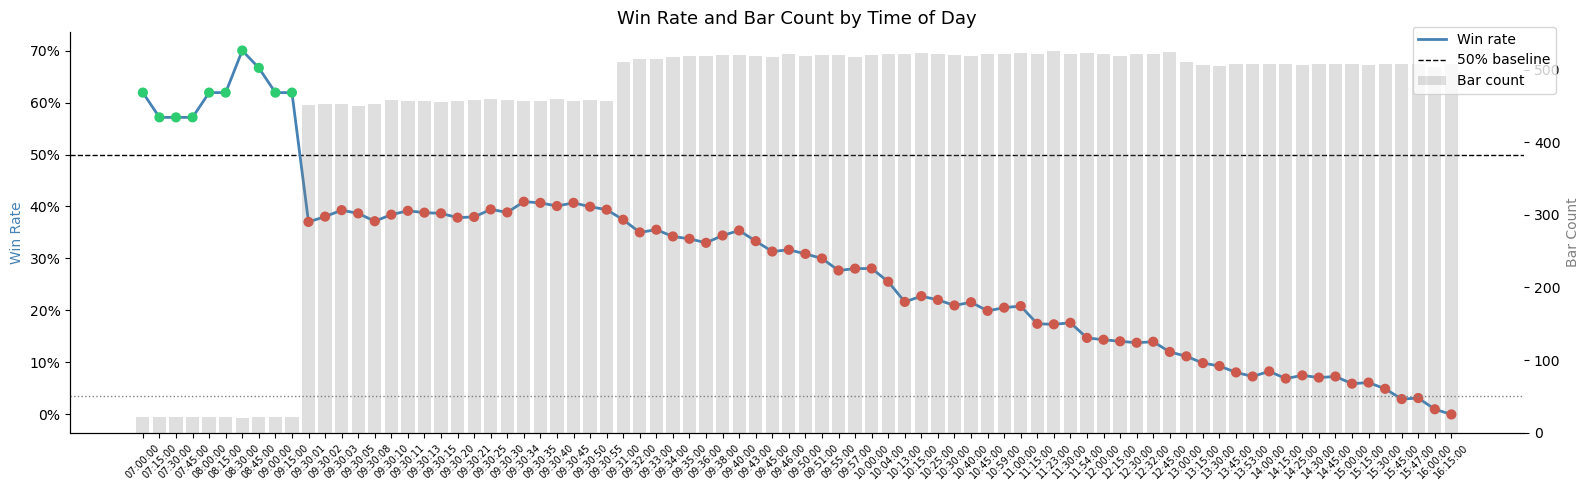


Top 10 time slots (N ≥ 50):
            n  win_rate
time                   
09:30:34  457  0.409190
09:30:45  457  0.407002
09:30:35  457  0.407002
09:30:40  459  0.400871
09:30:50  458  0.399563
09:30:25  459  0.394336
09:30:55  457  0.393873
09:30:03  453  0.392936
09:30:11  457  0.391685
09:30:30  458  0.388646

Bottom 10 time slots (N ≥ 50):
            n  win_rate
time                   
14:45:00  507  0.072978
14:30:00  508  0.070866
14:15:00  507  0.069034
15:15:00  506  0.061265
15:00:00  507  0.059172
15:30:00  507  0.049310
15:47:00  508  0.031496
15:45:00  508  0.029528
16:00:00  503  0.009940
16:15:00  507  0.000000


In [8]:
MIN_BARS = 50  # flag unreliable time slots

time_stats = (
    df.dropna(subset=['money_made', 'time'])
    .groupby('time')
    .agg(n=('money_made', 'count'),
         wins=('money_made', lambda x: (x == 'yes').sum()))
    .assign(win_rate=lambda x: x['wins'] / x['n'])
    .sort_index()
)

fig, ax1 = plt.subplots(figsize=(16, 5))

colors = bar_colors(time_stats['win_rate'].tolist())
ax1.plot(time_stats.index, time_stats['win_rate'], color='steelblue',
         linewidth=2, zorder=3, label='Win rate')
ax1.scatter(time_stats.index, time_stats['win_rate'], color=colors, s=40, zorder=4)
add_50pct_line(ax1)
fmt_pct(ax1)
ax1.set_ylabel('Win Rate', color='steelblue')
ax1.tick_params(axis='x', rotation=45, labelsize=7)

ax2 = ax1.twinx()
ax2.bar(time_stats.index, time_stats['n'], alpha=0.25, color='grey', label='Bar count')
ax2.set_ylabel('Bar Count', color='grey')
ax2.axhline(MIN_BARS, color='grey', linestyle=':', linewidth=1)

ax1.set_title('Win Rate and Bar Count by Time of Day', fontsize=13)
fig.legend(loc='upper right', bbox_to_anchor=(0.98, 0.95))
plt.tight_layout()
plt.show()

reliable = time_stats[time_stats['n'] >= MIN_BARS].sort_values('win_rate', ascending=False)
print(f'\nTop 10 time slots (N ≥ {MIN_BARS}):')
print(reliable.head(10)[['n', 'win_rate']].to_string())
print(f'\nBottom 10 time slots (N ≥ {MIN_BARS}):')
print(reliable.tail(10)[['n', 'win_rate']].to_string())

*Interpretation: Look for a time window where the line stays consistently above 50%. Dots below the bar chart's dotted line have fewer than 50 observations — treat those rates with caution. High win-rate times with high bar counts are the most actionable findings.*

---
## Section 5: Day-of-Week Analysis

Does the strategy perform consistently across all weekdays? Mondays and Fridays often have different volatility profiles (gap risk on Monday, position squaring on Friday).

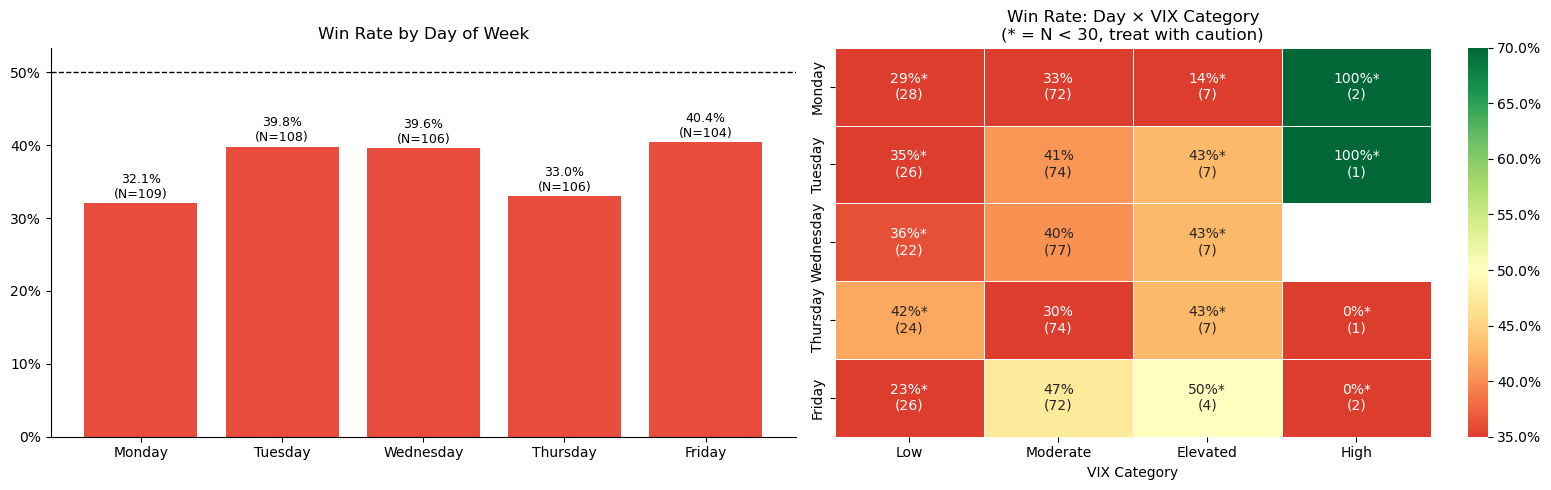

In [9]:
DOW_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']

dow_stats = (
    df_day.dropna(subset=['money_made'])
    .groupby('day_of_week')
    .agg(n=('money_made', 'count'),
         wins=('money_made', lambda x: (x == 'yes').sum()))
    .assign(win_rate=lambda x: x['wins'] / x['n'])
    .reindex([d for d in DOW_ORDER if d in df_day['day_of_week'].unique()])
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: win rate by day of week
days   = dow_stats.index.tolist()
rates  = dow_stats['win_rate'].tolist()
ns     = dow_stats['n'].tolist()
bars = axes[0].bar(days, rates, color=bar_colors(rates))
add_50pct_line(axes[0])
fmt_pct(axes[0])
for bar, rate, n in zip(bars, rates, ns):
    axes[0].text(bar.get_x() + bar.get_width()/2, rate + 0.003,
                 f'{rate:.1%}\n(N={n})', ha='center', va='bottom', fontsize=9)
axes[0].set_title('Win Rate by Day of Week')
axes[0].set_ylim(0, max(rates) + 0.13)

# Right: heatmap — day_of_week x vix_category
cat_order = ['Low', 'Moderate', 'Elevated', 'High']
pivot = (
    df_day.dropna(subset=['money_made', 'vix_category'])
    .groupby(['day_of_week', 'vix_category'])
    .agg(n=('money_made', 'count'),
         win_rate=('money_made', lambda x: (x == 'yes').mean()))
    .reset_index()
)
heatmap_rate = pivot.pivot(index='day_of_week', columns='vix_category', values='win_rate')
heatmap_n    = pivot.pivot(index='day_of_week', columns='vix_category', values='n')

# Reorder
heatmap_rate = heatmap_rate.reindex(index=[d for d in DOW_ORDER if d in heatmap_rate.index],
                                     columns=[c for c in cat_order if c in heatmap_rate.columns])
heatmap_n    = heatmap_n.reindex(   index=heatmap_rate.index, columns=heatmap_rate.columns)

# Mask cells with N < 30
annot = annotate_heatmap(heatmap_rate, heatmap_n, flag_threshold=30)

sns.heatmap(heatmap_rate, ax=axes[1], cmap='RdYlGn', center=0.5, vmin=0.35, vmax=0.70,
            annot=annot, fmt='', linewidths=0.5, cbar_kws={'format': mticker.PercentFormatter(xmax=1)})
axes[1].set_title('Win Rate: Day × VIX Category\n(* = N < 30, treat with caution)')
axes[1].set_xlabel('VIX Category')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

*Interpretation: If one or two days consistently outperform, a simple day-of-week filter could be added with no additional infrastructure. The heatmap reveals whether the VIX effect is consistent across all days or concentrated on specific days.*

---
## Section 6: Volatility Environment

Does the magnitude of the day's price range affect strategy performance? On low-volatility days, price may not move far enough to cross the contract strike. On extreme days, trending behavior may override mean-reversion.

C:\Users\lmjsp\AppData\Local\Temp\ipykernel_42388\2130998701.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(


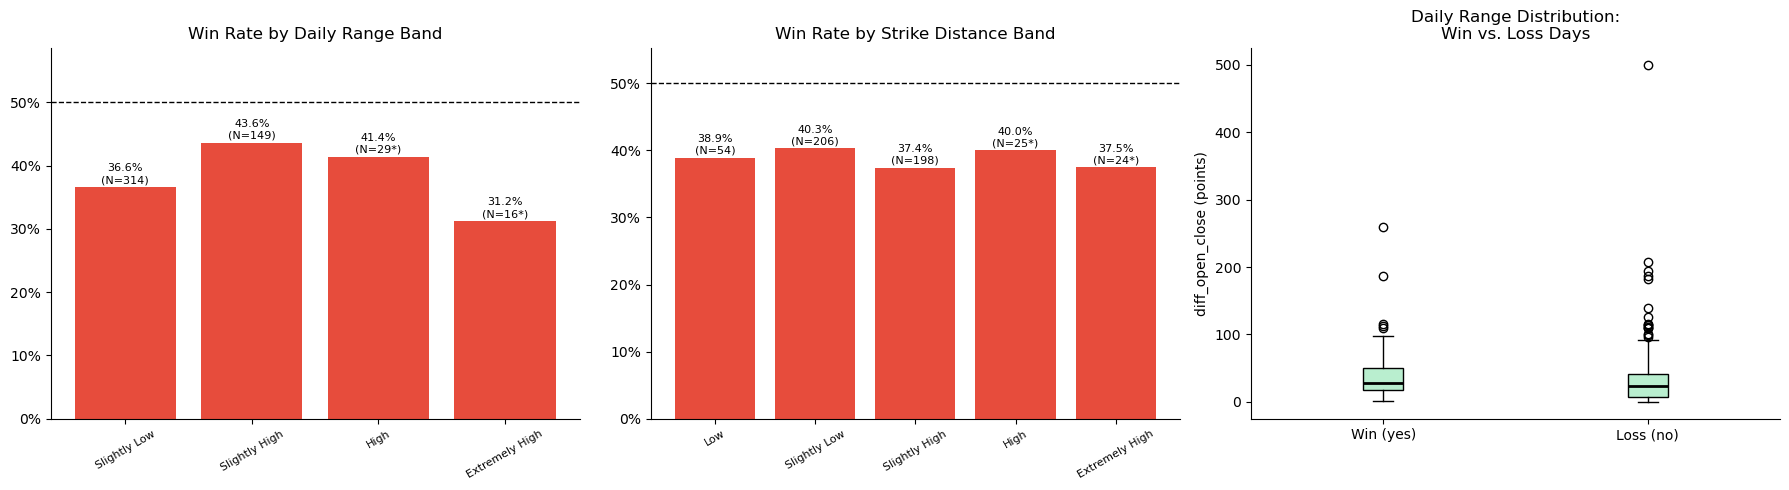

In [10]:
SDV_ORDER = ['Extremely Low', 'Low', 'Slightly Low', 'Slightly High', 'High', 'Extremely High']

def sdv_win_rate(col, label):
    stats = (
        df_day.dropna(subset=['money_made', col])
        .groupby(col)
        .agg(n=('money_made', 'count'),
             wins=('money_made', lambda x: (x == 'yes').sum()))
        .assign(win_rate=lambda x: x['wins'] / x['n'])
        .reindex([s for s in SDV_ORDER if s in df_day[col].dropna().unique()])
    )
    return stats

range_stats  = sdv_win_rate('open_close_diff_sdv_interval', 'Daily Range Band')
strike_stats = sdv_win_rate('open_conLoc_diff_sdv_interval', 'Strike Distance Band')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def plot_sdv_bars(ax, stats, title):
    cats  = stats.index.tolist()
    rates = stats['win_rate'].tolist()
    ns    = stats['n'].tolist()
    bars  = ax.bar(range(len(cats)), rates, color=bar_colors(rates), tick_label=cats)
    add_50pct_line(ax)
    fmt_pct(ax)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    for i, (rate, n) in enumerate(zip(rates, ns)):
        flag = '*' if n < 30 else ''
        ax.text(i, rate + 0.003, f'{rate:.1%}\n(N={n}{flag})', ha='center', va='bottom', fontsize=8)
    ax.set_title(title)
    ax.set_ylim(0, max(rates) + 0.15 if rates else 0.7)

plot_sdv_bars(axes[0], range_stats,  'Win Rate by Daily Range Band')
plot_sdv_bars(axes[1], strike_stats, 'Win Rate by Strike Distance Band')

# Box plot: diff_open_close by money_made
df_box = df_day.dropna(subset=['money_made', 'diff_open_close'])
axes[2].boxplot(
    [df_box[df_box['money_made'] == 'yes']['diff_open_close'].values,
     df_box[df_box['money_made'] == 'no']['diff_open_close'].values],
    labels=['Win (yes)', 'Loss (no)'],
    patch_artist=True,
    boxprops=dict(facecolor='#2ecc7155'),
    medianprops=dict(color='black', linewidth=2)
)
axes[2].set_title('Daily Range Distribution:\nWin vs. Loss Days')
axes[2].set_ylabel('diff_open_close (points)')

plt.tight_layout()
plt.show()

*Interpretation: If low-range days have poor win rates, a minimum volatility filter could be added. If farther strikes (high `open_conLoc_diff_sdv_interval`) consistently underperform, strike selection logic should be tightened. The box plot reveals whether winning days tend to have larger ranges (price had room to move to the strike).*

---
## Section 7: Trend Over Time

Is the strategy stable, or is it deteriorating? A strategy that worked in 2018 but not in 2023 is not tradeable today. The rolling 90-day win rate is the most important chart for assessing drift.

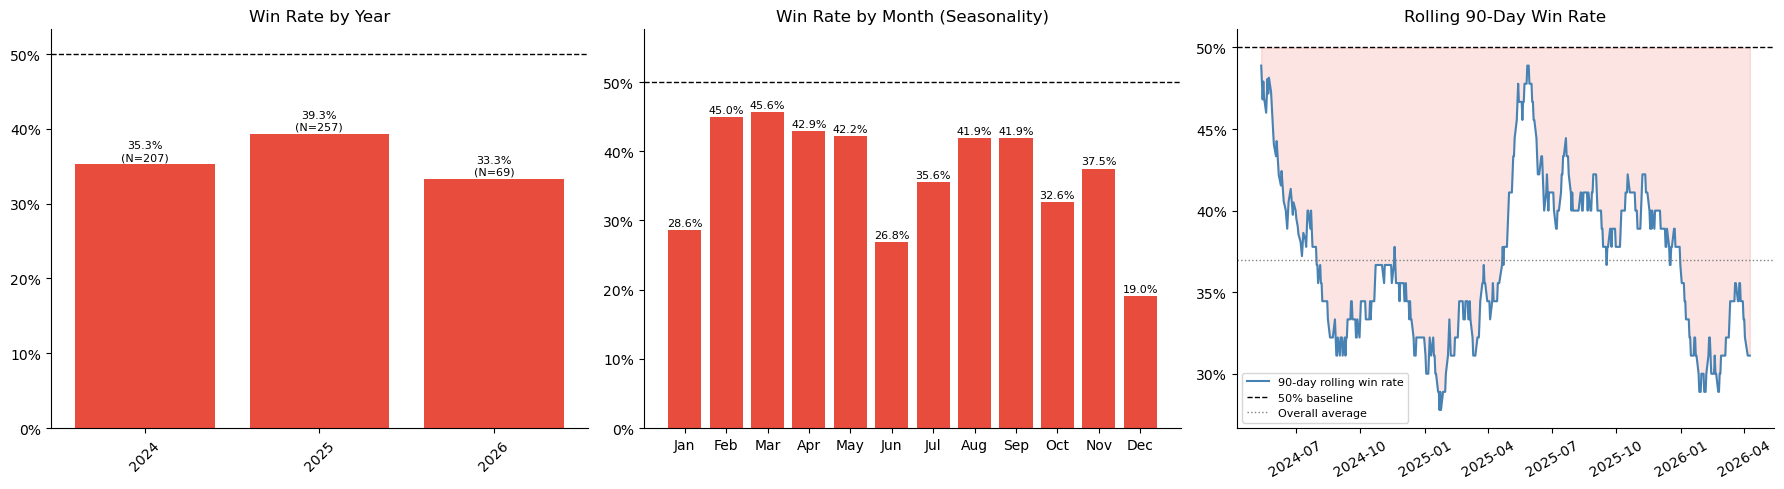

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Win rate by year
yr_stats = (
    df_day.dropna(subset=['money_made'])
    .groupby('year')
    .agg(n=('money_made', 'count'),
         wins=('money_made', lambda x: (x == 'yes').sum()))
    .assign(win_rate=lambda x: x['wins'] / x['n'])
)
bars_y = axes[0].bar(yr_stats.index.astype(str), yr_stats['win_rate'],
                      color=bar_colors(yr_stats['win_rate'].tolist()))
add_50pct_line(axes[0])
fmt_pct(axes[0])
for bar, (yr, row) in zip(bars_y, yr_stats.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2, row.win_rate + 0.003,
                 f'{row.win_rate:.1%}\n(N={row.n:.0f})', ha='center', va='bottom', fontsize=8)
axes[0].set_title('Win Rate by Year')
axes[0].set_ylim(0, yr_stats['win_rate'].max() + 0.14)
axes[0].tick_params(axis='x', rotation=45)

# Win rate by month
mo_stats = (
    df_day.dropna(subset=['money_made'])
    .groupby('month')
    .agg(n=('money_made', 'count'),
         wins=('money_made', lambda x: (x == 'yes').sum()))
    .assign(win_rate=lambda x: x['wins'] / x['n'])
)
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
bars_m = axes[1].bar(
    mo_stats.index.map(lambda m: month_labels[m-1]),
    mo_stats['win_rate'],
    color=bar_colors(mo_stats['win_rate'].tolist())
)
add_50pct_line(axes[1])
fmt_pct(axes[1])
for bar, (mo, row) in zip(bars_m, mo_stats.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2, row.win_rate + 0.003,
                 f'{row.win_rate:.1%}', ha='center', va='bottom', fontsize=8)
axes[1].set_title('Win Rate by Month (Seasonality)')
axes[1].set_ylim(0, mo_stats['win_rate'].max() + 0.12)

# Rolling 90-day win rate
daily_sorted = df_day.dropna(subset=['money_made']).sort_values('date').copy()
daily_sorted['win_binary'] = (daily_sorted['money_made'] == 'yes').astype(int)
daily_sorted['rolling_90'] = daily_sorted['win_binary'].rolling(90, min_periods=45).mean()

axes[2].plot(daily_sorted['date'], daily_sorted['rolling_90'],
             color='steelblue', linewidth=1.5, label='90-day rolling win rate')
axes[2].axhline(0.50, color='black', linestyle='--', linewidth=1, label='50% baseline')
axes[2].axhline(daily_sorted['win_binary'].mean(), color='grey',
                linestyle=':', linewidth=1, label='Overall average')
axes[2].fill_between(daily_sorted['date'], 0.50, daily_sorted['rolling_90'],
                      where=daily_sorted['rolling_90'] >= 0.50,
                      alpha=0.15, color='#2ecc71')
axes[2].fill_between(daily_sorted['date'], 0.50, daily_sorted['rolling_90'],
                      where=daily_sorted['rolling_90'] < 0.50,
                      alpha=0.15, color='#e74c3c')
fmt_pct(axes[2])
axes[2].set_title('Rolling 90-Day Win Rate')
axes[2].legend(fontsize=8)
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

*Interpretation: A flat or gently rising rolling line is a green flag — the strategy is stable. A sharply declining line suggests the edge is eroding. If the line dips below 50% for extended periods, identify what was happening in the market at that time (e.g., 2020 COVID volatility, 2022 rate-hike trend).*

---
## Section 8: Initial Direction Analysis

Is the strategy symmetric — does it perform equally well when price opens above vs. below the reference? If one direction is significantly stronger, we might only trade that direction.

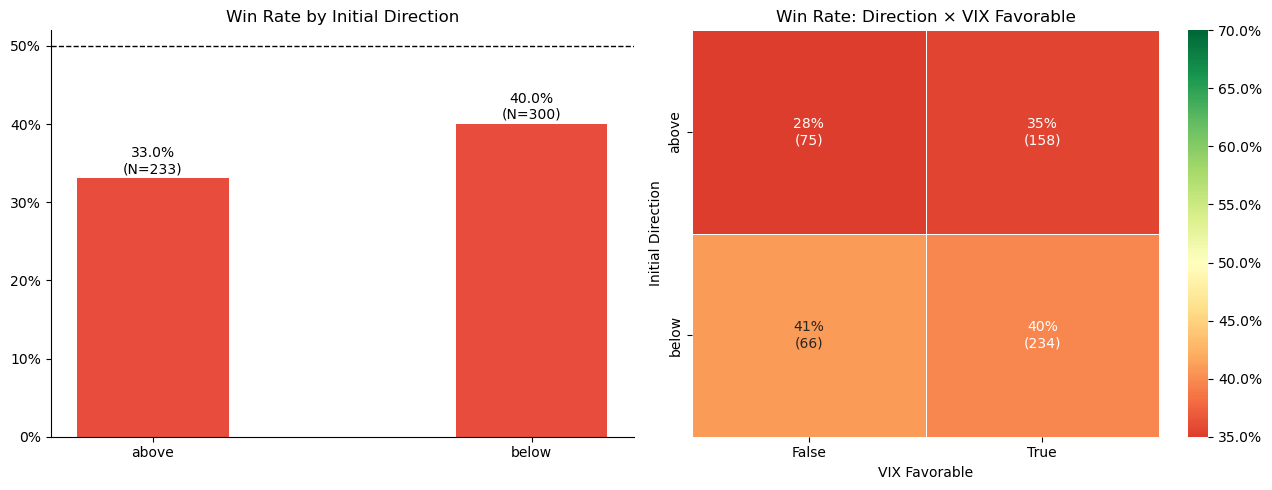

In [12]:
dir_stats = (
    df_day.dropna(subset=['money_made', 'initial_direction'])
    .groupby('initial_direction')
    .agg(n=('money_made', 'count'),
         wins=('money_made', lambda x: (x == 'yes').sum()))
    .assign(win_rate=lambda x: x['wins'] / x['n'])
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: win rate by initial direction
dirs  = dir_stats.index.tolist()
rates = dir_stats['win_rate'].tolist()
ns    = dir_stats['n'].tolist()
bars = axes[0].bar(dirs, rates, color=bar_colors(rates), width=0.4)
add_50pct_line(axes[0])
fmt_pct(axes[0])
for bar, rate, n in zip(bars, rates, ns):
    axes[0].text(bar.get_x() + bar.get_width()/2, rate + 0.003,
                 f'{rate:.1%}\n(N={n})', ha='center', va='bottom')
axes[0].set_title('Win Rate by Initial Direction')
axes[0].set_ylim(0, max(rates) + 0.12)

# Right: 2x2 — direction x vix_favorable
cross = (
    df_day.dropna(subset=['money_made', 'initial_direction', 'vix_favorable'])
    .groupby(['initial_direction', 'vix_favorable'])
    .agg(n=('money_made', 'count'),
         win_rate=('money_made', lambda x: (x == 'yes').mean()))
    .reset_index()
)
pivot_cross = cross.pivot(index='initial_direction', columns='vix_favorable',
                           values='win_rate')
pivot_n     = cross.pivot(index='initial_direction', columns='vix_favorable',
                           values='n')

annot_cross = annotate_heatmap(pivot_cross, pivot_n)

sns.heatmap(pivot_cross, ax=axes[1], cmap='RdYlGn', center=0.5, vmin=0.35, vmax=0.70,
            annot=annot_cross, fmt='', linewidths=0.5,
            cbar_kws={'format': mticker.PercentFormatter(xmax=1)})
axes[1].set_title('Win Rate: Direction × VIX Favorable')
axes[1].set_xlabel('VIX Favorable')
axes[1].set_ylabel('Initial Direction')

plt.tight_layout()
plt.show()

*Interpretation: If 'above' (sell trade) and 'below' (buy trade) show similar win rates, the strategy is symmetric and both directions are valid. A large gap suggests only trading the stronger direction. The heatmap shows whether the VIX filter helps both directions equally or is more valuable for one.*

---
## Section 9: Win/Loss Streak Analysis

Are wins and losses independent, or do they cluster into streaks? Heavy loss clustering is a risk management concern. If the win rate drops significantly after a long win streak, that is a signal to reduce size.

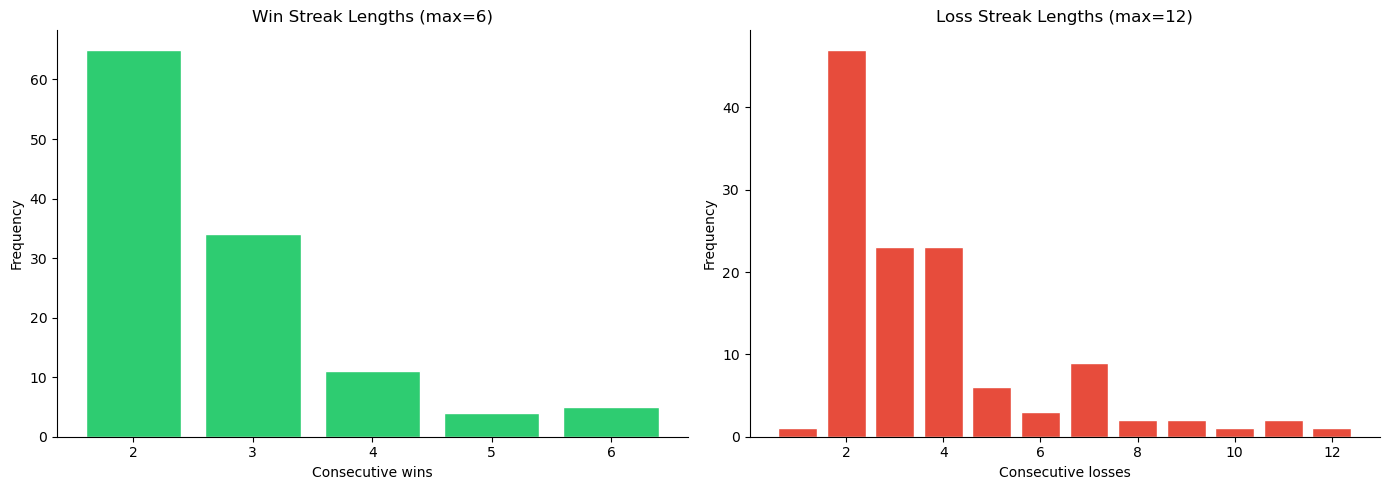

Win rate on the NEXT day, following a win/loss streak of length N:
(Uses overall_win_streak and overall_loss_streak from preparing.ipynb)

 Streak N After win streak (N)  Sample (wins) After loss streak (N)  Sample (losses)
        1                  N/A              0                 33.3%                3
        2                43.0%            114                 39.8%              118
        3                34.6%             52                 31.9%               72
        4                38.9%             18                 44.2%               52
        5                50.0%              8                 21.4%               28
        6                 0.0%              5                 14.3%               21
        7                  N/A              0                 50.0%               18


In [13]:
daily_s = df_day.sort_values('date').dropna(subset=['money_made', 'overall_win_streak', 'overall_loss_streak'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Streak length distributions
max_win  = int(daily_s['overall_win_streak'].max())
max_loss = int(daily_s['overall_loss_streak'].max())

# Count how many times each streak length was the PEAK of a run
# (i.e., where the next value resets to 0)
def streak_peaks(col):
    s = daily_s[col]
    peaks = s[(s > 0) & (s.shift(-1).fillna(0) == 0)]
    return peaks.value_counts().sort_index()

win_peaks  = streak_peaks('overall_win_streak')
loss_peaks = streak_peaks('overall_loss_streak')

axes[0].bar(win_peaks.index, win_peaks.values, color='#2ecc71', edgecolor='white')
axes[0].set_title(f'Win Streak Lengths (max={max_win})')
axes[0].set_xlabel('Consecutive wins')
axes[0].set_ylabel('Frequency')

axes[1].bar(loss_peaks.index, loss_peaks.values, color='#e74c3c', edgecolor='white')
axes[1].set_title(f'Loss Streak Lengths (max={max_loss})')
axes[1].set_xlabel('Consecutive losses')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Win rate following N-game streaks
print('Win rate on the NEXT day, following a win/loss streak of length N:')
print('(Uses overall_win_streak and overall_loss_streak from preparing.ipynb)\n')

# Compute next calendar day's outcome for every row BEFORE filtering.
# shift(-1) on the full sorted daily_s gives the actual next trading day,
# not the next row that happens to match the same streak length.
daily_s = daily_s.copy()
daily_s['next_outcome'] = daily_s['money_made'].shift(-1)

rows = []
for n_streak in range(1, 8):
    after_win  = daily_s.loc[daily_s['overall_win_streak']  == n_streak, 'next_outcome']
    after_loss = daily_s.loc[daily_s['overall_loss_streak'] == n_streak, 'next_outcome']
    wr_after_win  = (after_win  == 'yes').sum() / after_win.notna().sum()  if after_win.notna().sum() > 0 else np.nan
    wr_after_loss = (after_loss == 'yes').sum() / after_loss.notna().sum() if after_loss.notna().sum() > 0 else np.nan
    rows.append({
        'Streak N': n_streak,
        'After win streak (N)': f'{wr_after_win:.1%}' if not np.isnan(wr_after_win) else 'N/A',
        'Sample (wins)': after_win.notna().sum(),
        'After loss streak (N)': f'{wr_after_loss:.1%}' if not np.isnan(wr_after_loss) else 'N/A',
        'Sample (losses)': after_loss.notna().sum(),
    })

streak_table = pd.DataFrame(rows)
print(streak_table.to_string(index=False))

*Interpretation: If loss streaks rarely exceed 4–5 in a row, a drawdown of 5 losses is a normal event — not a signal to stop trading. If the win rate after a 5-game win streak is noticeably lower than the baseline, consider reducing position size. Small sample sizes (N < 20) make these streak-conditional rates unreliable.*

---
## Section 10: Combined Best-Case Conditions

Combine the top filters from earlier sections to find the highest-confidence setup. Then check: how often do those conditions actually occur? A 70% win rate that fires 8 times per year is not very useful.

In [14]:
# ── Edit these filters based on findings in Sections 3–8 ─────────────────────
# These are starting defaults that can be tuned after reviewing the above sections.

BEST_VIX_FAVORABLE  = True                         # Section 3 finding
BEST_DOW            = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']  # update after Section 5
BEST_SDV_BANDS      = ['Slightly Low', 'Slightly High', 'High', 'Extremely High']  # update after Section 6
BEST_DIRECTION      = ['above', 'below']           # update after Section 8 if asymmetric

# ── Apply combined filter ─────────────────────────────────────────────────────
mask_combined = (
    (df_day['vix_favorable'] == BEST_VIX_FAVORABLE) &
    (df_day['day_of_week'].isin(BEST_DOW)) &
    (df_day['open_close_diff_sdv_interval'].isin(BEST_SDV_BANDS)) &
    (df_day['initial_direction'].isin(BEST_DIRECTION))
)

best = df_day[mask_combined].dropna(subset=['money_made'])
best_rate = (best['money_made'] == 'yes').mean()
years_span = (df_day['date'].max() - df_day['date'].min()).days / 365.25

print('=' * 55)
print(f'  Combined filter: N = {len(best):,} days')
print(f'  Win rate        : {best_rate:.1%}')
print(f'  % of all days   : {len(best)/len(df_day)*100:.1f}%')
print(f'  Est. trades/yr  : {len(best)/years_span:.0f}')
print('=' * 55)

  Combined filter: N = 377 days
  Win rate        : 39.5%
  % of all days   : 70.7%
  Est. trades/yr  : 181


In [15]:
# ── Sensitivity table — vary VIX and DOW filter ───────────────────────────────
results = []
for vix_fav in [True, False, None]:    # None = no VIX filter
    for sdv_tight in [True, False]:    # True = only 'Slightly High', 'High', 'Extremely High'
        vix_mask = (
            df_day['vix_favorable'] == vix_fav if vix_fav is not None
            else pd.Series(True, index=df_day.index)
        )
        sdv_vals = (['Slightly High', 'High', 'Extremely High'] if sdv_tight
                    else ['Slightly Low', 'Slightly High', 'High', 'Extremely High', 'Low'])
        sdv_mask = df_day['open_close_diff_sdv_interval'].isin(sdv_vals)
        subset   = df_day[vix_mask & sdv_mask].dropna(subset=['money_made'])
        rate     = (subset['money_made'] == 'yes').mean()
        label_vix = ('VIX fav' if vix_fav is True else
                     ('VIX unfav' if vix_fav is False else 'No VIX filter'))
        label_sdv = 'SDV tight' if sdv_tight else 'SDV broad'
        results.append({
            'VIX filter': label_vix,
            'Volatility filter': label_sdv,
            'N days': len(subset),
            'Win rate': f'{rate:.1%}',
            'Est. trades/yr': f'{len(subset)/years_span:.0f}',
        })

sens_df = pd.DataFrame(results)
print('Sensitivity Table — Win Rate vs. Filter Tightness')
print(sens_df.to_string(index=False))

Sensitivity Table — Win Rate vs. Filter Tightness
   VIX filter Volatility filter  N days Win rate Est. trades/yr
      VIX fav         SDV tight     155    43.9%             75
      VIX fav         SDV broad     377    39.5%            181
    VIX unfav         SDV tight      39    35.9%             19
    VIX unfav         SDV broad     131    36.6%             63
No VIX filter         SDV tight     194    42.3%             93
No VIX filter         SDV broad     508    38.8%            244


*Interpretation: The sensitivity table shows the quality vs. quantity tradeoff. Look for the row with the best win rate that still produces a reasonable number of annual trades. A combined filter should ideally produce 50+ trades per year to be statistically useful going forward.*

---
## Section 11: Summary & Conclusions

*Fill in after running all sections above.*

### Findings

| Section | Question | Finding |
|---|---|---|
| 2 | Does the strategy beat 50%? | *(fill in: overall win rate, p-value)* |
| 3 | Does VIX filter improve win rate? | *(fill in: rate favorable vs. unfavorable)* |
| 4 | Best time-of-day window? | *(fill in: top time slots)* |
| 5 | Best days of week? | *(fill in: top 2 days)* |
| 6 | Optimal volatility range? | *(fill in: best SDV bands)* |
| 7 | Is strategy stable over time? | *(fill in: rolling win rate trend)* |
| 8 | Is strategy symmetric by direction? | *(fill in: above vs. below rates)* |
| 9 | Worst streak risk? | *(fill in: max loss streak length)* |
| 10 | Best combined win rate? | *(fill in: combined rate, trades/yr)* |

---

### Recommendation

*(Fill in: go / conditional go / no-go, with the specific filter conditions)*

---

### What This Analysis Cannot Answer

- **Transaction costs** — Nadex binary options have a fee per contract; this must be modeled against the win rate to determine net profitability
- **Slippage** — Contract fills may not be at the exact strike level; real-world fills could differ
- **Contract expiry mechanics** — The binary option expires at a fixed time; end-of-day close may not equal the expiry price
- **Out-of-sample performance** — All analysis above uses the full dataset; true out-of-sample testing requires holding back a period (e.g., the last 6 months) and testing on that only
- **Position sizing** — This analysis only measures win rate, not optimal bet size (Kelly criterion or fixed-fraction sizing)

---

### Suggested Next Steps

1. **Update `fixedConLocUpTo03-5-24.xlsx`** — Add contract locations beyond 2024-03-05 to expand the dataset
2. **Out-of-sample test** — Re-run `preparing.ipynb` on a held-out period (e.g., post-March 2024) and check if the combined filter holds
3. **Model transaction costs** — Estimate net P&L per trade given Nadex fee structure and your typical contract size
4. **Paper trade** — Run the filtered strategy rules live on Nadex in paper mode for 30+ days before committing capital

---
## Section 12: Early-Session Signal Analysis

Two questions:
1. Does the **magnitude of price movement** in the first 30 minutes predict whether the strategy wins or loses?
2. Does a **volume spike** in the first 30 minutes tell us anything about the true initial direction? *(Note: volume data only available for 145 of 533 days — treat as exploratory.)*

The core question: can we filter out low-confidence days *before* entry, based on early session behaviour?

### 12a — Price Distance from Open in First 30 Minutes

In [16]:
import datetime

# ── Build first-30-min bar summary per day ────────────────────────────────────
df['time_parsed'] = pd.to_datetime(df['time'], format='%H:%M:%S').dt.time
open_t = datetime.time(9, 30, 0)
cut_t  = datetime.time(10, 0, 0)

early = df[(df['time_parsed'] >= open_t) & (df['time_parsed'] <= cut_t)].copy()

early_summary = (
    early.groupby('date')
    .agg(
        high_30m   = ('candle_high_price',  'max'),
        low_30m    = ('candle_low_price',   'min'),
        last_30m   = ('candle_close_price', 'last'),
        n_bars_30m = ('time_parsed',        'count'),
    )
    .reset_index()
)

# Merge with day-level data
dm = df_day.merge(early_summary, on='date', how='inner')
dm = dm.dropna(subset=['money_made', 'market_open_09:30', 'contract_location'])

# ── Key metrics ───────────────────────────────────────────────────────────────
# 1. Range of first 30 mins as % of open (volatility proxy)
dm['range_pct'] = (dm['high_30m'] - dm['low_30m']) / dm['market_open_09:30'] * 100

# 2. Net directional drift from open to end of 30-min window
dm['drift_pct'] = (dm['last_30m'] - dm['market_open_09:30']) / dm['market_open_09:30'] * 100

# 3. Max move AWAY from contract location in first 30 mins
#    (how far price ran in the wrong direction before potential reversal)
dm['open_vs_loc'] = dm['market_open_09:30'] - dm['contract_location']
dm['max_away_pct'] = np.where(
    dm['open_vs_loc'] > 0,   # opened above contract loc — wrong way is further up
    (dm['high_30m'] - dm['contract_location']) / dm['market_open_09:30'] * 100,
    (dm['contract_location'] - dm['low_30m'])  / dm['market_open_09:30'] * 100,
)

dm['won'] = (dm['money_made'] == 'yes').astype(int)

print(f'Days in dataset: {len(dm)}')
print(f'Overall win rate: {dm["won"].mean():.1%}')
print()
print('First-30-min range stats (% of open):')
print(dm['range_pct'].describe().round(3))


Days in dataset: 507
Overall win rate: 38.9%

First-30-min range stats (% of open):
count    507.000
mean       0.410
std        0.268
min        0.070
25%        0.228
50%        0.351
75%        0.518
max        3.187
Name: range_pct, dtype: float64


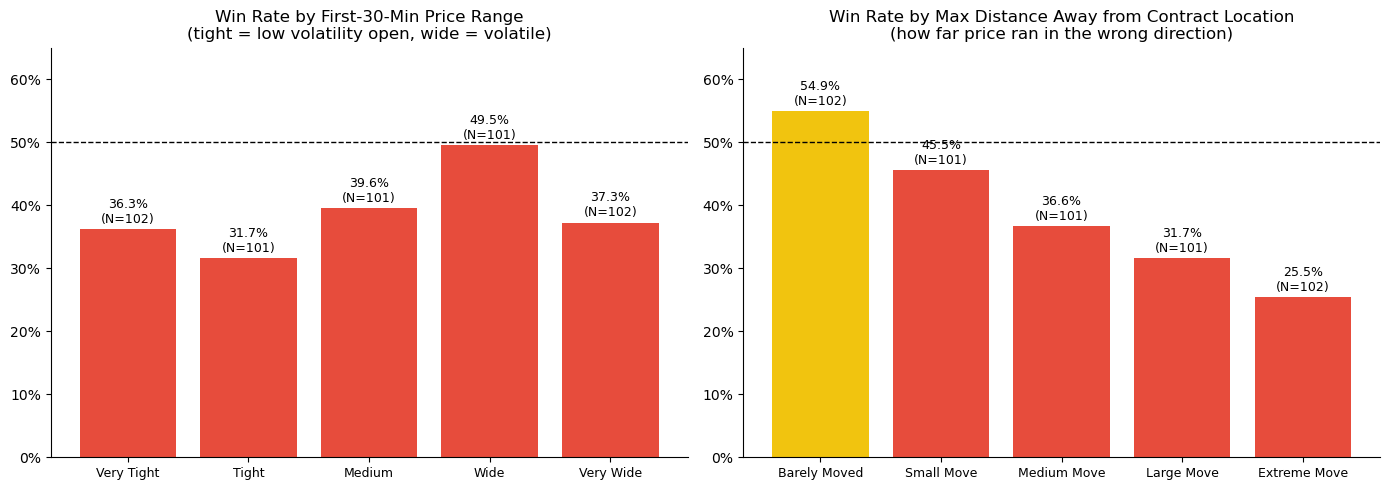

Range bucket breakdown:
                n  win_rate  range_pct_mid
range_bucket                              
Very Tight    102     0.363          0.169
Tight         101     0.317          0.259
Medium        101     0.396          0.351
Wide          101     0.495          0.476
Very Wide     102     0.373          0.717

Max-away-from-location bucket breakdown:
                n  win_rate  max_away_mid
away_bucket                              
Barely Moved  102     0.549         0.104
Small Move    101     0.455         0.190
Medium Move   101     0.366         0.275
Large Move    101     0.317         0.380
Extreme Move  102     0.255         0.615


In [17]:
# ── Win rate by first-30-min range and max-away buckets ──────────────────────
dm['range_bucket'] = pd.qcut(dm['range_pct'], q=5,
    labels=['Very Tight', 'Tight', 'Medium', 'Wide', 'Very Wide'])

dm['away_bucket'] = pd.qcut(dm['max_away_pct'], q=5,
    labels=['Barely Moved', 'Small Move', 'Medium Move', 'Large Move', 'Extreme Move'])

range_stats = (
    dm.groupby('range_bucket', observed=True)
    .agg(n=('won', 'count'), win_rate=('won', 'mean'), range_pct_mid=('range_pct', 'median'))
)
away_stats = (
    dm.groupby('away_bucket', observed=True)
    .agg(n=('won', 'count'), win_rate=('won', 'mean'), max_away_mid=('max_away_pct', 'median'))
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: win rate by range bucket
labels_r = range_stats.index.tolist()
rates_r  = range_stats['win_rate'].tolist()
ns_r     = range_stats['n'].tolist()
bars = axes[0].bar(labels_r, rates_r, color=bar_colors(rates_r))
add_50pct_line(axes[0])
fmt_pct(axes[0])
for bar, rate, n in zip(bars, rates_r, ns_r):
    axes[0].text(bar.get_x() + bar.get_width()/2, rate + 0.005,
                 f'{rate:.1%}\n(N={n})', ha='center', va='bottom', fontsize=9)
axes[0].set_title('Win Rate by First-30-Min Price Range\n(tight = low volatility open, wide = volatile)')
axes[0].set_ylim(0, 0.65)
axes[0].tick_params(axis='x', labelsize=9)

# Right: win rate by max-away bucket
labels_a = away_stats.index.tolist()
rates_a  = away_stats['win_rate'].tolist()
ns_a     = away_stats['n'].tolist()
bars2 = axes[1].bar(labels_a, rates_a, color=bar_colors(rates_a))
add_50pct_line(axes[1])
fmt_pct(axes[1])
for bar, rate, n in zip(bars2, rates_a, ns_a):
    axes[1].text(bar.get_x() + bar.get_width()/2, rate + 0.005,
                 f'{rate:.1%}\n(N={n})', ha='center', va='bottom', fontsize=9)
axes[1].set_title('Win Rate by Max Distance Away from Contract Location\n(how far price ran in the wrong direction)')
axes[1].set_ylim(0, 0.65)
axes[1].tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.show()

print('Range bucket breakdown:')
print(range_stats[['n', 'win_rate', 'range_pct_mid']].round(3).to_string())
print()
print('Max-away-from-location bucket breakdown:')
print(away_stats[['n', 'win_rate', 'max_away_mid']].round(3).to_string())


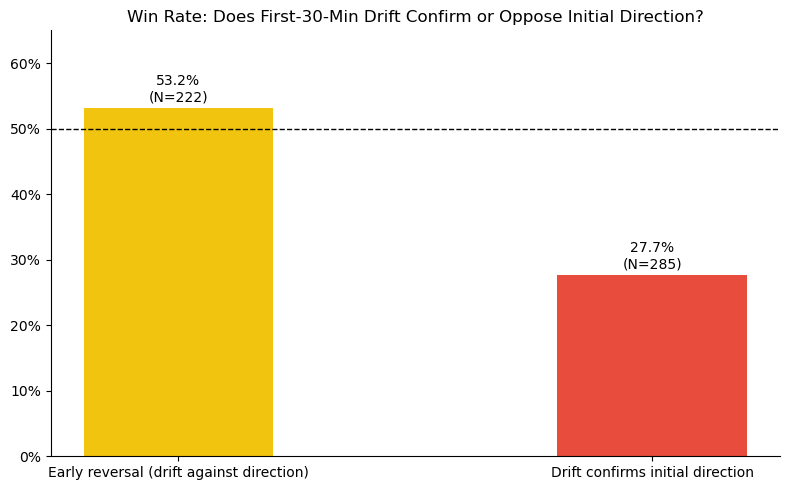

                                            n  win_rate
Early reversal (drift against direction)  222     0.532
Drift confirms initial direction          285     0.277


In [18]:
# ── Does 30-min drift CONFIRM or CONTRADICT the initial direction? ───────────
# If drift is positive (price went up) and initial_direction=above,
# market confirmed the direction → mean reversion less likely.
# If drift is negative and initial_direction=above, early pull-back started → more hopeful.

dm['drift_confirms_direction'] = np.where(
    dm['initial_direction'] == 'above',
    dm['drift_pct'] > 0,   # above: upward drift confirms direction (bad for strategy)
    dm['drift_pct'] < 0,   # below: downward drift confirms direction (bad for strategy)
)

confirm_stats = (
    dm.groupby('drift_confirms_direction')
    .agg(n=('won', 'count'), win_rate=('won', 'mean'))
)
confirm_stats.index = ['Early reversal (drift against direction)',
                       'Drift confirms initial direction']

fig, ax = plt.subplots(figsize=(8, 5))
labels_c = confirm_stats.index.tolist()
rates_c  = confirm_stats['win_rate'].tolist()
ns_c     = confirm_stats['n'].tolist()
bars = ax.bar(labels_c, rates_c, color=bar_colors(rates_c), width=0.4)
add_50pct_line(ax)
fmt_pct(ax)
for bar, rate, n in zip(bars, rates_c, ns_c):
    ax.text(bar.get_x() + bar.get_width()/2, rate + 0.005,
            f'{rate:.1%}\n(N={n})', ha='center', va='bottom')
ax.set_title('Win Rate: Does First-30-Min Drift Confirm or Oppose Initial Direction?')
ax.set_ylim(0, 0.65)
plt.tight_layout()
plt.show()

print(confirm_stats[['n', 'win_rate']].round(3).to_string())


### 12b — Volume Spike Analysis *(145-day subset, Apr–Nov 2024)*

*Volume is missing for the majority of days. Treat these findings as directional only — sample is too small to draw firm conclusions.*

In [19]:
# ── Volume in first 30 mins vs rest of day ────────────────────────────────────
vol_df = df[df['volume'] > 0].copy()
vol_df['time_parsed'] = pd.to_datetime(vol_df['time'], format='%H:%M:%S').dt.time

vol_days      = vol_df['date'].unique()
vol_df_early  = vol_df[(vol_df['time_parsed'] >= open_t) & (vol_df['time_parsed'] <= cut_t)]

vol_day_summary = (
    vol_df.groupby('date').agg(total_vol=('volume', 'sum')).reset_index()
)
vol_early_summary = (
    vol_df_early.groupby('date').agg(vol_30m=('volume', 'sum')).reset_index()
)
vol_summary = vol_day_summary.merge(vol_early_summary, on='date', how='left').fillna(0)
vol_summary['pct_vol_30m'] = vol_summary['vol_30m'] / vol_summary['total_vol'] * 100

dv = df_day[df_day['date'].isin(vol_days)].merge(vol_summary, on='date', how='inner')
dv = dv.dropna(subset=['money_made'])
dv['won'] = (dv['money_made'] == 'yes').astype(int)

print(f'Days with volume data: {len(dv)}')
print(f'Win rate on volume-data days: {dv["won"].mean():.1%}')
print()
print('Volume distribution (first 30 mins as % of day total):')
print(dv['pct_vol_30m'].describe().round(1))


Days with volume data: 145
Win rate on volume-data days: 35.9%

Volume distribution (first 30 mins as % of day total):
count    145.0
mean      41.6
std        6.7
min       27.2
25%       37.2
50%       41.6
75%       44.9
max       65.5
Name: pct_vol_30m, dtype: float64


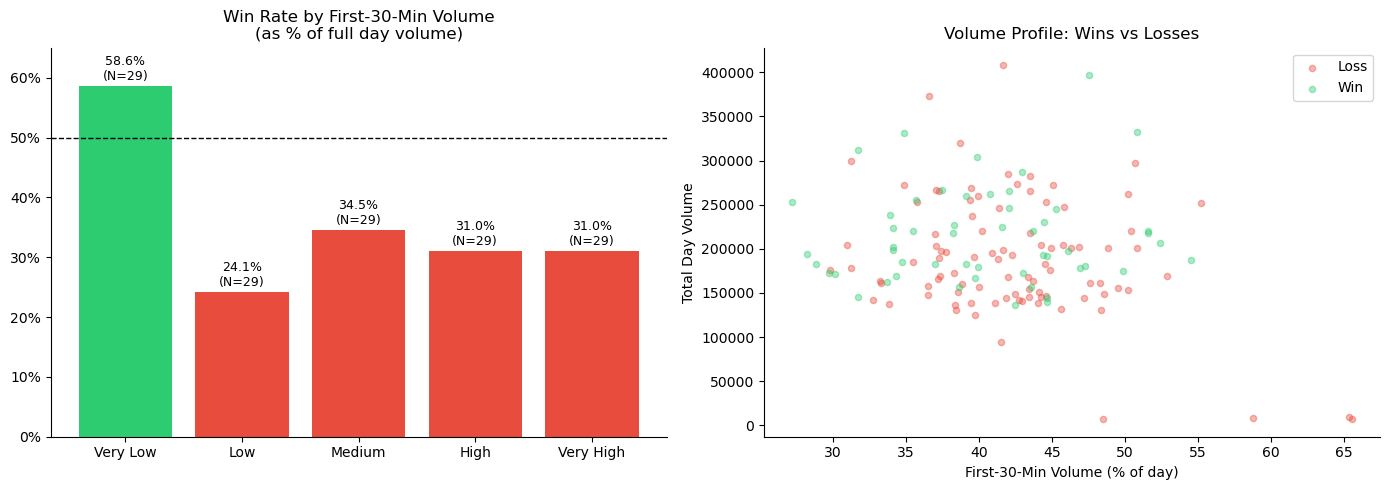

Volume bucket breakdown:
             n  win_rate  pct_30m_mid
vol_bucket                           
Very Low    29     0.586       33.715
Low         29     0.241       38.273
Medium      29     0.345       41.615
High        29     0.310       44.410
Very High   29     0.310       50.217


In [20]:
# ── Win rate by first-30-min volume quintile ──────────────────────────────────
dv['vol_bucket'] = pd.qcut(dv['pct_vol_30m'], q=5,
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'],
    duplicates='drop')

vol_stats = (
    dv.groupby('vol_bucket', observed=True)
    .agg(n=('won', 'count'), win_rate=('won', 'mean'), pct_30m_mid=('pct_vol_30m', 'median'))
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels_v = vol_stats.index.tolist()
rates_v  = vol_stats['win_rate'].tolist()
ns_v     = vol_stats['n'].tolist()
bars = axes[0].bar(labels_v, rates_v, color=bar_colors(rates_v))
add_50pct_line(axes[0])
fmt_pct(axes[0])
for bar, rate, n in zip(bars, rates_v, ns_v):
    axes[0].text(bar.get_x() + bar.get_width()/2, rate + 0.005,
                 f'{rate:.1%}\n(N={n})', ha='center', va='bottom', fontsize=9)
axes[0].set_title('Win Rate by First-30-Min Volume\n(as % of full day volume)')
axes[0].set_ylim(0, 0.65)

won_days  = dv[dv['won'] == 1]
lost_days = dv[dv['won'] == 0]
axes[1].scatter(lost_days['pct_vol_30m'], lost_days['total_vol'],
                alpha=0.4, color='#e74c3c', label='Loss', s=20)
axes[1].scatter(won_days['pct_vol_30m'],  won_days['total_vol'],
                alpha=0.4, color='#2ecc71', label='Win',  s=20)
axes[1].set_xlabel('First-30-Min Volume (% of day)')
axes[1].set_ylabel('Total Day Volume')
axes[1].set_title('Volume Profile: Wins vs Losses')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Volume bucket breakdown:')
print(vol_stats[['n', 'win_rate', 'pct_30m_mid']].round(3).to_string())


### 12c — Combined Signal: Tight Range + Early Reversal

In [21]:
# ── Best-case filter: tight first-30-min range AND drift already reversing ────
# Hypothesis: tight open = less conviction in initial direction.
# Early reversal drift = market already pulling back before entry.
# Together, these should be the highest-confidence setup for mean reversion.

range_median = dm['range_pct'].median()

dm['tight_open']     = dm['range_pct'] < range_median
dm['early_reversal'] = ~dm['drift_confirms_direction']

combos = [
    ('Tight open + early reversal',   dm['tight_open'] &  dm['early_reversal']),
    ('Tight open, drift confirms',    dm['tight_open'] & ~dm['early_reversal']),
    ('Wide open + early reversal',   ~dm['tight_open'] &  dm['early_reversal']),
    ('Wide open, drift confirms',    ~dm['tight_open'] & ~dm['early_reversal']),
]

rows = []
for label, mask in combos:
    subset = dm[mask]
    rows.append({
        'Condition':  label,
        'N':          len(subset),
        'Win rate':   f'{subset["won"].mean():.1%}' if len(subset) > 0 else 'N/A',
        '% of days':  f'{len(subset)/len(dm):.1%}',
    })

combo_df = pd.DataFrame(rows)
print('Combined Signal Analysis:')
print(combo_df.to_string(index=False))
print()
print(f'Baseline win rate (all days): {dm["won"].mean():.1%}')
print(f'Range median used as threshold: {range_median:.3f}%')


Combined Signal Analysis:
                  Condition   N Win rate % of days
Tight open + early reversal  95    43.2%     18.7%
 Tight open, drift confirms 158    29.1%     31.2%
 Wide open + early reversal 127    60.6%     25.0%
  Wide open, drift confirms 127    26.0%     25.0%

Baseline win rate (all days): 38.9%
Range median used as threshold: 0.351%


*Interpretation: Look for conditions that lift win rate meaningfully above the 37% baseline. A tight first-30-min range suggests less conviction in the initial direction — potentially easier to reverse. An early reversal in the 30-min drift means the market is already questioning the initial direction before you enter. If the combined filter still cannot reach 50%+, the mean-reversion hypothesis is unlikely to be salvageable with price/volume signals alone.*

### 12d — Triple Filter: Wide Open + Early Reversal + Price Close to Contract Location

The two strongest signals from 12a and 12c combined:
- **Wide open** — first-30-min range above median (volatile, directional open)
- **Early reversal** — 30-min drift already pulling back against initial direction
- **Barely moved** — max distance from contract location in bottom 40% (price hasn't run far from where it needs to end up)

In [22]:
# ── Triple filter: wide open + early reversal + close to contract location ────
away_40th = dm['max_away_pct'].quantile(0.40)

dm['close_to_loc'] = dm['max_away_pct'] <= away_40th

combos = [
    ('Wide + reversal + close to loc',  dm['tight_open'] == False,  dm['early_reversal'],  dm['close_to_loc']),
    ('Wide + reversal, far from loc',   dm['tight_open'] == False,  dm['early_reversal'],  ~dm['close_to_loc']),
    ('Wide + reversal (all)',            dm['tight_open'] == False,  dm['early_reversal'],  pd.Series([True]*len(dm), index=dm.index)),
]

rows = []
for label, m1, m2, m3 in combos:
    mask = m1 & m2 & m3
    subset = dm[mask]
    n = len(subset)
    wr = subset['won'].mean() if n > 0 else float('nan')
    rows.append({
        'Condition':       label,
        'N':               n,
        'Win rate':        f'{wr:.1%}' if n > 0 else 'N/A',
        '% of all days':   f'{n/len(dm):.1%}',
        'Est. trades/yr':  f'{n / (len(dm)/252):.0f}',
    })

# Also show the full breakdown for context
print('Triple Filter Results:')
print(pd.DataFrame(rows).to_string(index=False))
print()

# ── Deeper cut: wide + reversal, binned by max_away_pct ──────────────────────
wide_rev = dm[(dm['tight_open'] == False) & (dm['early_reversal'])]
wide_rev = wide_rev.copy()
wide_rev['away_bucket'] = pd.qcut(wide_rev['max_away_pct'], q=4,
    labels=['Closest (Q1)', 'Near (Q2)', 'Far (Q3)', 'Furthest (Q4)'])

deep = (
    wide_rev.groupby('away_bucket', observed=True)
    .agg(n=('won', 'count'), win_rate=('won', 'mean'), away_mid=('max_away_pct', 'median'))
)

print('Within Wide + Early Reversal days — win rate by distance from contract location:')
print(deep[['n', 'win_rate', 'away_mid']].round(3).to_string())
print()
print(f'Baseline (all days): {dm["won"].mean():.1%}')
print(f'Wide + reversal (all): {wide_rev["won"].mean():.1%}  (N={len(wide_rev)})')
print(f'Bottom-40% away threshold used: {away_40th:.3f}%')


Triple Filter Results:
                     Condition   N Win rate % of all days Est. trades/yr
Wide + reversal + close to loc  66    68.2%         13.0%             33
 Wide + reversal, far from loc  61    52.5%         12.0%             30
         Wide + reversal (all) 127    60.6%         25.0%             63

Within Wide + Early Reversal days — win rate by distance from contract location:
                n  win_rate  away_mid
away_bucket                          
Closest (Q1)   32     0.719     0.093
Near (Q2)      32     0.625     0.180
Far (Q3)       31     0.645     0.279
Furthest (Q4)  32     0.438     0.426

Baseline (all days): 38.9%
Wide + reversal (all): 60.6%  (N=127)
Bottom-40% away threshold used: 0.230%


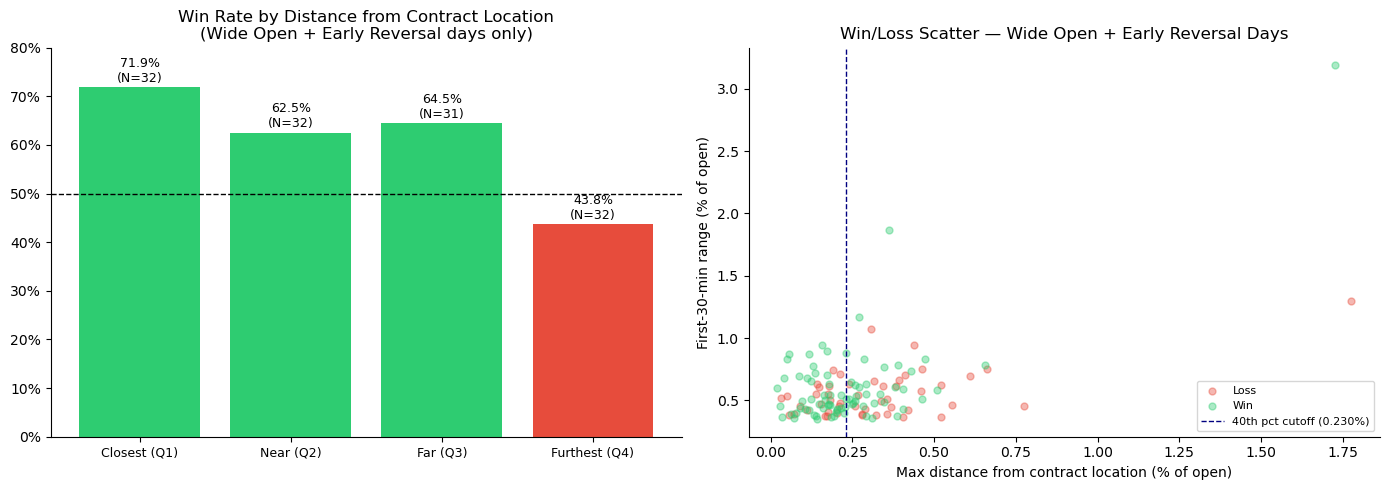

In [23]:
# ── Chart: win rate across the 4 distance quartiles within Wide+Reversal days ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: bar chart of win rate by distance quartile (within wide+reversal)
labels_d = deep.index.tolist()
rates_d  = deep['win_rate'].tolist()
ns_d     = deep['n'].tolist()
bars = axes[0].bar(labels_d, rates_d, color=bar_colors(rates_d))
add_50pct_line(axes[0])
fmt_pct(axes[0])
for bar, rate, n in zip(bars, rates_d, ns_d):
    axes[0].text(bar.get_x() + bar.get_width()/2, rate + 0.005,
                 f'{rate:.1%}\n(N={n})', ha='center', va='bottom', fontsize=9)
axes[0].set_title('Win Rate by Distance from Contract Location\n(Wide Open + Early Reversal days only)')
axes[0].set_ylim(0, 0.80)
axes[0].tick_params(axis='x', labelsize=9)

# Right: scatter of max_away_pct vs outcome on Wide+Reversal days
won_wr  = wide_rev[wide_rev['won'] == 1]
lost_wr = wide_rev[wide_rev['won'] == 0]
axes[1].scatter(lost_wr['max_away_pct'], lost_wr['range_pct'],
                alpha=0.4, color='#e74c3c', label='Loss', s=25)
axes[1].scatter(won_wr['max_away_pct'],  won_wr['range_pct'],
                alpha=0.4, color='#2ecc71', label='Win',  s=25)
axes[1].axvline(away_40th, color='navy', linestyle='--', linewidth=1,
                label=f'40th pct cutoff ({away_40th:.3f}%)')
axes[1].set_xlabel('Max distance from contract location (% of open)')
axes[1].set_ylabel('First-30-min range (% of open)')
axes[1].set_title('Win/Loss Scatter — Wide Open + Early Reversal Days')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


*Interpretation: Within the already-filtered Wide + Early Reversal days, does being close to the contract location add further edge? If Q1 (closest) shows materially higher win rate than Q4 (furthest), the max-away filter is additive. If the win rates are similar across quartiles, the wide+reversal filter is doing most of the work on its own and the distance filter doesn't add much.*

---
## Section 13: Drift Magnitude Analysis & Calendar Lens

Building on the 127-day Wide + Early Reversal subset (60.6% win rate).

Three questions:
1. **13a — Drift magnitude vs final move**: does a *bigger* pullback at 10am predict a *bigger* day? Can we predict how far the reversal will carry?
2. **13b — Progress toward contract**: by 10am, how much of the gap to the contract location has drift already covered? Does more progress = higher win rate?
3. **13c — Calendar lens**: do day-of-week, month, or position within the month add any edge on top of the Wide + Reversal filter?

**Sample size note:** The W+R subset has 127 days over ~2 years. DOW gives ~25 days/bucket (marginal but usable). Month gives ~10/bucket (exploratory only — patterns here are hypothesis-generators, not filters). Day-of-month is grouped into 4 period buckets (~30 each) to keep it meaningful.

### 13a — Drift Magnitude vs Final Move

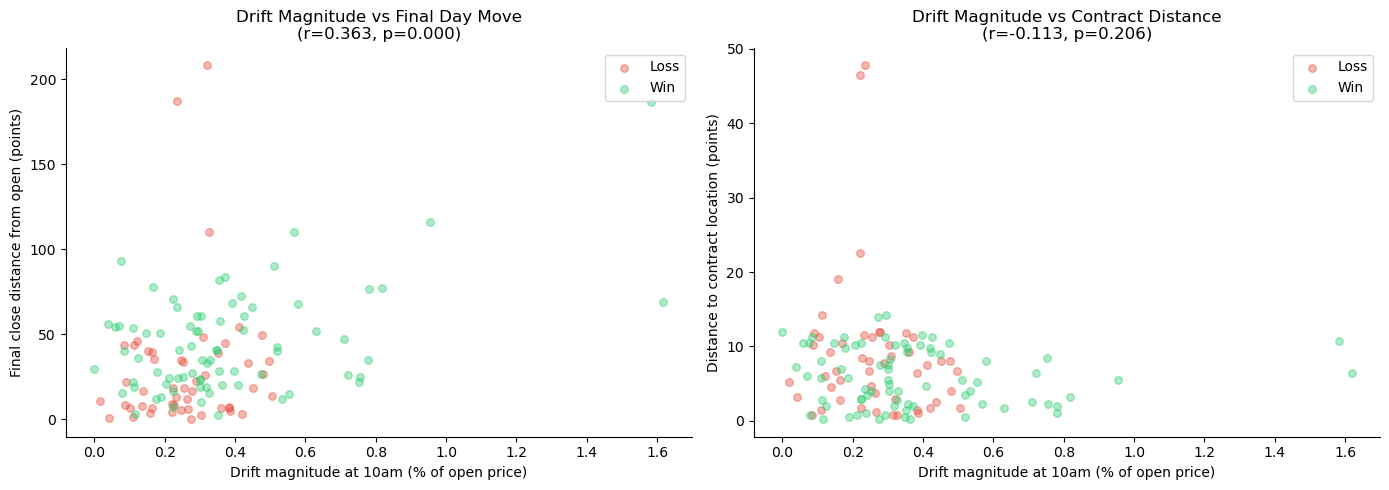

Wide + Early Reversal days: 127

Pearson r — drift magnitude vs final close distance : 0.363  (p=0.0000)
Pearson r — drift magnitude vs contract distance    : -0.113  (p=0.2060)

Interpretation: |r| < 0.2 = negligible  |  0.2–0.4 = weak  |  0.4–0.6 = moderate  |  >0.6 = strong

Drift magnitude summary stats:
count    127.0000
mean       0.3312
std        0.2432
min        0.0000
25%        0.1815
50%        0.2934
75%        0.4031
max        1.6184
Name: drift_magnitude, dtype: float64


In [24]:
import scipy.stats as stats_mod

# ── Re-derive the Wide + Early Reversal subset (same logic as Section 12) ──
# Requires: dm, tight_open, early_reversal columns from Section 12 cells
wide_rev13 = dm[(dm['tight_open'] == False) & (dm['early_reversal'])].copy()
wide_rev13['drift_magnitude'] = wide_rev13['drift_pct'].abs()

# ── Pearson correlation: drift magnitude vs final close distance ──────────────
r_close,  p_close  = stats_mod.pearsonr(wide_rev13['drift_magnitude'], wide_rev13['diff_open_close'])
r_conloc, p_conloc = stats_mod.pearsonr(wide_rev13['drift_magnitude'], wide_rev13['diff_open_conLoc'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

won_wr13  = wide_rev13[wide_rev13['won'] == 1]
lost_wr13 = wide_rev13[wide_rev13['won'] == 0]

# Left: drift magnitude vs actual final close distance
axes[0].scatter(lost_wr13['drift_magnitude'], lost_wr13['diff_open_close'],
                alpha=0.4, color='#e74c3c', label='Loss', s=30)
axes[0].scatter(won_wr13['drift_magnitude'],  won_wr13['diff_open_close'],
                alpha=0.4, color='#2ecc71', label='Win',  s=30)
axes[0].set_xlabel('Drift magnitude at 10am (% of open price)')
axes[0].set_ylabel('Final close distance from open (points)')
axes[0].set_title(f'Drift Magnitude vs Final Day Move\n(r={r_close:.3f}, p={p_close:.3f})')
axes[0].legend()

# Right: drift magnitude vs distance to contract location
axes[1].scatter(lost_wr13['drift_magnitude'], lost_wr13['diff_open_conLoc'],
                alpha=0.4, color='#e74c3c', label='Loss', s=30)
axes[1].scatter(won_wr13['drift_magnitude'],  won_wr13['diff_open_conLoc'],
                alpha=0.4, color='#2ecc71', label='Win',  s=30)
axes[1].set_xlabel('Drift magnitude at 10am (% of open price)')
axes[1].set_ylabel('Distance to contract location (points)')
axes[1].set_title(f'Drift Magnitude vs Contract Distance\n(r={r_conloc:.3f}, p={p_conloc:.3f})')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Wide + Early Reversal days: {len(wide_rev13)}')
print()
print(f'Pearson r — drift magnitude vs final close distance : {r_close:.3f}  (p={p_close:.4f})')
print(f'Pearson r — drift magnitude vs contract distance    : {r_conloc:.3f}  (p={p_conloc:.4f})')
print()
print('Interpretation: |r| < 0.2 = negligible  |  0.2–0.4 = weak  |  0.4–0.6 = moderate  |  >0.6 = strong')
print()
print('Drift magnitude summary stats:')
print(wide_rev13['drift_magnitude'].describe().round(4))


### 13b — Drift Magnitude Bins: Win Rate and Predicted Range

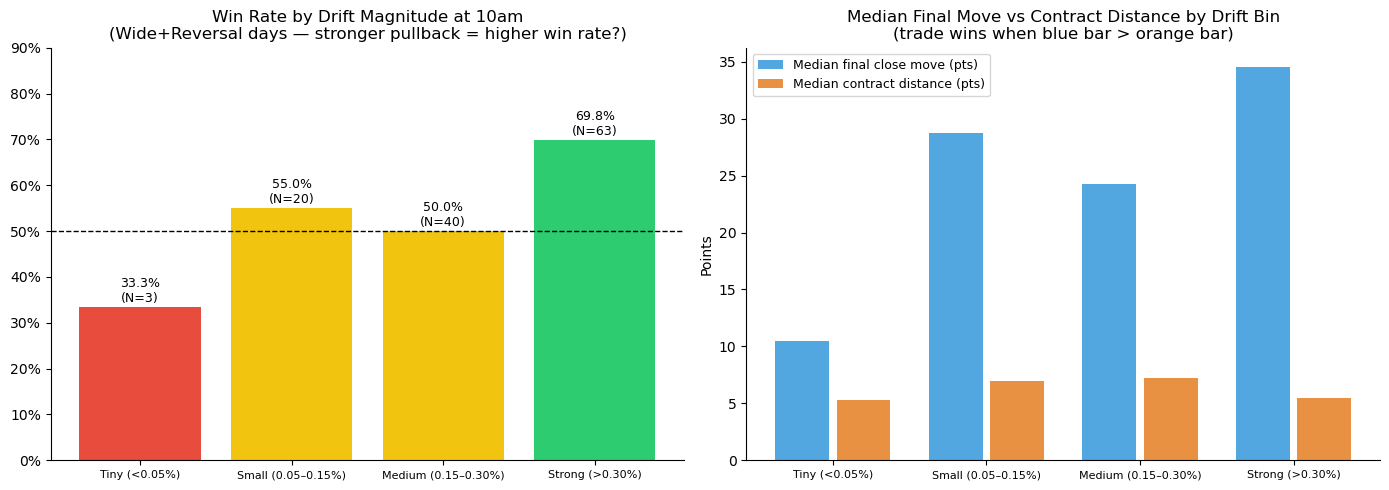

Drift magnitude breakdown (Wide+Reversal days):
                      n  win_rate  median_final_pts  median_contract_dist  drift_mid
drift_bin                                                                           
Tiny (<0.05%)         3     0.333             10.50                  5.25      0.038
Small (0.05–0.15%)   20     0.550             28.75                  7.00      0.110
Medium (0.15–0.30%)  40     0.500             24.25                  7.25      0.233
Strong (>0.30%)      63     0.698             34.50                  5.50      0.409


In [25]:
# ── Bin drift magnitude and compare win rate + final move vs contract distance ─
# Bin boundaries in % of open price (ES ~5000 → 0.05% ≈ 2.5 pts, 0.15% ≈ 7.5 pts, 0.30% ≈ 15 pts)
wide_rev13['drift_bin'] = pd.cut(
    wide_rev13['drift_magnitude'],
    bins=[0, 0.05, 0.15, 0.30, 99.0],
    labels=['Tiny (<0.05%)', 'Small (0.05–0.15%)', 'Medium (0.15–0.30%)', 'Strong (>0.30%)']
)

drift_stats = (
    wide_rev13.groupby('drift_bin', observed=True)
    .agg(
        n                    = ('won',              'count'),
        win_rate             = ('won',              'mean'),
        median_final_pts     = ('diff_open_close',  'median'),
        median_contract_dist = ('diff_open_conLoc', 'median'),
        drift_mid            = ('drift_magnitude',  'median'),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: win rate by drift magnitude bin
labels_b = drift_stats.index.tolist()
rates_b  = drift_stats['win_rate'].tolist()
ns_b     = drift_stats['n'].tolist()
bars = axes[0].bar(labels_b, rates_b, color=bar_colors(rates_b))
add_50pct_line(axes[0])
fmt_pct(axes[0])
for bar, rate, n in zip(bars, rates_b, ns_b):
    axes[0].text(bar.get_x() + bar.get_width()/2, rate + 0.005,
                 f'{rate:.1%}\n(N={n})', ha='center', va='bottom', fontsize=9)
axes[0].set_title('Win Rate by Drift Magnitude at 10am\n(Wide+Reversal days — stronger pullback = higher win rate?)')
axes[0].set_ylim(0, 0.90)
axes[0].tick_params(axis='x', labelsize=8)

# Right: median final move (blue) vs median contract distance (orange)
# The trade wins when final move clears the contract distance — blue should exceed orange
x_pos = range(len(drift_stats))
axes[1].bar([x - 0.2 for x in x_pos], drift_stats['median_final_pts'], width=0.35,
            label='Median final close move (pts)', color='#3498db', alpha=0.85)
axes[1].bar([x + 0.2 for x in x_pos], drift_stats['median_contract_dist'], width=0.35,
            label='Median contract distance (pts)', color='#e67e22', alpha=0.85)
axes[1].set_xticks(list(x_pos))
axes[1].set_xticklabels(labels_b, fontsize=8)
axes[1].set_title('Median Final Move vs Contract Distance by Drift Bin\n(trade wins when blue bar > orange bar)')
axes[1].legend(fontsize=9)
axes[1].set_ylabel('Points')

plt.tight_layout()
plt.show()

print('Drift magnitude breakdown (Wide+Reversal days):')
print(drift_stats[['n', 'win_rate', 'median_final_pts', 'median_contract_dist', 'drift_mid']].round(3).to_string())


### 13c — Progress Toward Contract at 10am

By 10am, drift has already moved price some fraction of the way toward the contract location.
`progress_ratio = drift_pts / diff_open_conLoc`
where `drift_pts = |drift_pct| / 100 × market_open_09:30` (converts % back to actual points).

- **<25%**: drift barely started — price just crossed back through the 9:30 open
- **25–50%**: moderate progress — one quarter to half the gap to the contract covered
- **50–100%**: majority of gap covered — price well on its way to the contract
- **>100%**: price has already *passed* the contract location by 10am (binary essentially locked in)

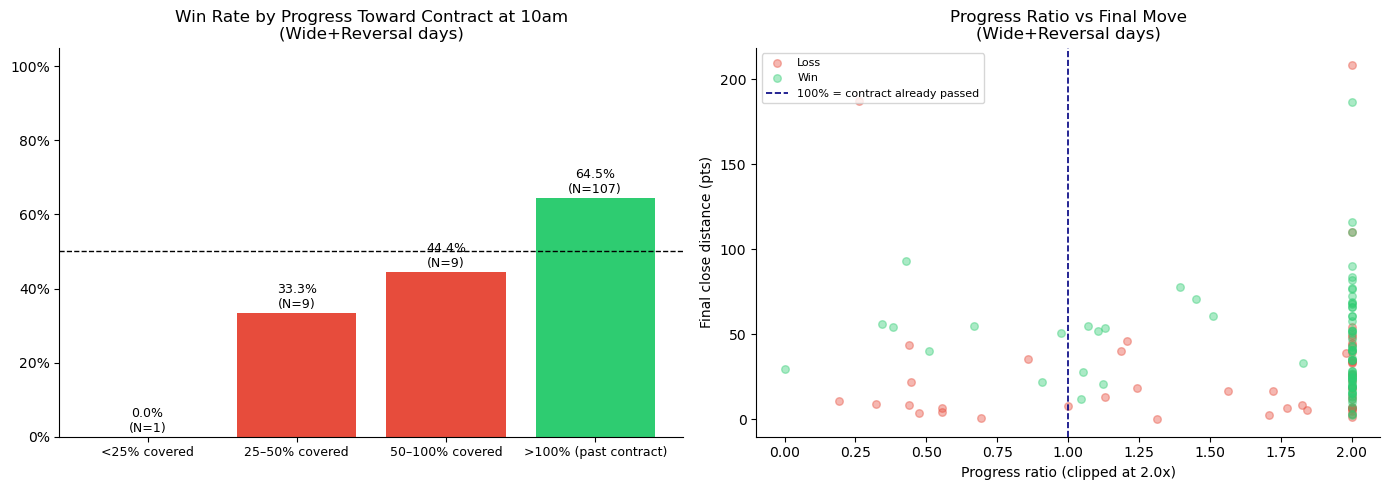

Progress toward contract breakdown:
                         n  win_rate  ratio_mid
progress_bin                                   
<25% covered             1     0.000      0.190
25–50% covered           9     0.333      0.429
50–100% covered          9     0.444      0.692
>100% (past contract)  107     0.645      3.562

Days already past contract by 10am   : 108  (win rate: 63.9%)
Win rate — progress < 25%            : 50.0%
Win rate — progress 25–50%           : 33.3%
Win rate — progress 50–100%          : 50.0%


In [26]:
# ── Progress toward contract: how much of the needed gap has been covered by 10am? ─
wide_rev13['drift_pts']      = wide_rev13['drift_magnitude'] / 100 * wide_rev13['market_open_09:30']
wide_rev13['progress_ratio'] = wide_rev13['drift_pts'] / wide_rev13['diff_open_conLoc']

wide_rev13['progress_bin'] = pd.cut(
    wide_rev13['progress_ratio'],
    bins=[0, 0.25, 0.50, 1.0, 999.0],
    labels=['<25% covered', '25–50% covered', '50–100% covered', '>100% (past contract)']
)

prog_stats = (
    wide_rev13.groupby('progress_bin', observed=True)
    .agg(n=('won', 'count'), win_rate=('won', 'mean'), ratio_mid=('progress_ratio', 'median'))
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels_p = prog_stats.index.tolist()
rates_p  = prog_stats['win_rate'].tolist()
ns_p     = prog_stats['n'].tolist()
bars = axes[0].bar(labels_p, rates_p, color=bar_colors(rates_p))
add_50pct_line(axes[0])
fmt_pct(axes[0])
for bar, rate, n in zip(bars, rates_p, ns_p):
    axes[0].text(bar.get_x() + bar.get_width()/2, rate + 0.005,
                 f'{rate:.1%}\n(N={n})', ha='center', va='bottom', fontsize=9)
axes[0].set_title('Win Rate by Progress Toward Contract at 10am\n(Wide+Reversal days)')
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis='x', labelsize=9)

won_p  = wide_rev13[wide_rev13['won'] == 1]
lost_p = wide_rev13[wide_rev13['won'] == 0]
axes[1].scatter(lost_p['progress_ratio'].clip(upper=2), lost_p['diff_open_close'],
                alpha=0.4, color='#e74c3c', label='Loss', s=30)
axes[1].scatter(won_p['progress_ratio'].clip(upper=2),  won_p['diff_open_close'],
                alpha=0.4, color='#2ecc71', label='Win',  s=30)
axes[1].axvline(1.0, color='navy', linestyle='--', linewidth=1.2,
                label='100% = contract already passed')
axes[1].set_xlabel('Progress ratio (clipped at 2.0x)')
axes[1].set_ylabel('Final close distance (pts)')
axes[1].set_title('Progress Ratio vs Final Move\n(Wide+Reversal days)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print('Progress toward contract breakdown:')
print(prog_stats[['n', 'win_rate', 'ratio_mid']].round(3).to_string())
print()
n_past = (wide_rev13['progress_ratio'] >= 1.0).sum()
wr_lt25  = wide_rev13.loc[wide_rev13['progress_ratio'] < 0.25, 'won'].mean()
wr_25_50 = wide_rev13.loc[(wide_rev13['progress_ratio'] >= 0.25) & (wide_rev13['progress_ratio'] < 0.50), 'won'].mean()
wr_50_100 = wide_rev13.loc[(wide_rev13['progress_ratio'] >= 0.50) & (wide_rev13['progress_ratio'] < 1.0), 'won'].mean()
wr_past  = wide_rev13.loc[wide_rev13['progress_ratio'] >= 1.0, 'won'].mean()
print(f'Days already past contract by 10am   : {n_past}  (win rate: {wr_past:.1%})')
print(f'Win rate — progress < 25%            : {wr_lt25:.1%}')
print(f'Win rate — progress 25–50%           : {wr_25_50:.1%}')
print(f'Win rate — progress 50–100%          : {wr_50_100:.1%}')


### 13d — Calendar Lens: Day of Week, Month, and Day-of-Month Period

**Caution on sample sizes:** 127 days over ~2 years.
- **DOW**: ~25/weekday — marginal, interpret cautiously. Any pattern here would need to persist into new data to be trusted.
- **Month**: ~10/month — exploratory only. Do *not* use as a hard entry filter. Flag strong outliers as hypotheses to watch.
- **Day-of-month period**: ~30/bucket — the most reliable of the three. The turn-of-month effect (days 1–7 tend bullish due to institutional fund flows) is a documented anomaly that could suppress or amplify mean reversion.

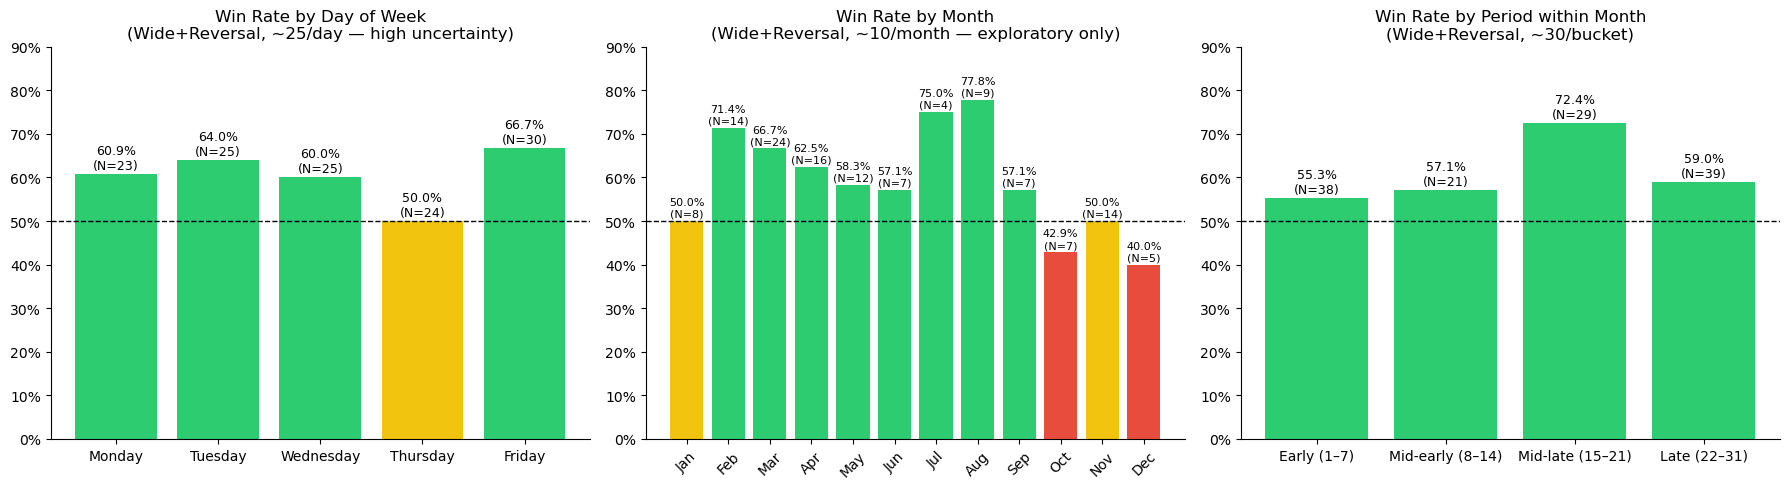

Day of week (Wide+Reversal):
            n  win_rate
dow_name               
Monday     23     0.609
Tuesday    25     0.640
Wednesday  25     0.600
Thursday   24     0.500
Friday     30     0.667

Month of year (exploratory):
             n  win_rate
month_name              
Jan          8     0.500
Feb         14     0.714
Mar         24     0.667
Apr         16     0.625
May         12     0.583
Jun          7     0.571
Jul          4     0.750
Aug          9     0.778
Sep          7     0.571
Oct          7     0.429
Nov         14     0.500
Dec          5     0.400

Day-of-month period:
                   n  win_rate
month_period                  
Early (1–7)       38     0.553
Mid-early (8–14)  21     0.571
Mid-late (15–21)  29     0.724
Late (22–31)      39     0.590


In [27]:
# ── Calendar features ─────────────────────────────────────────────────────────
wide_rev13['date_parsed']  = pd.to_datetime(wide_rev13['date'])
wide_rev13['dow_name']     = wide_rev13['date_parsed'].dt.day_name()
wide_rev13['month_name']   = wide_rev13['date_parsed'].dt.strftime('%b')
wide_rev13['day_of_month'] = wide_rev13['date_parsed'].dt.day
wide_rev13['month_period'] = pd.cut(
    wide_rev13['day_of_month'],
    bins=[0, 7, 14, 21, 31],
    labels=['Early (1–7)', 'Mid-early (8–14)', 'Mid-late (15–21)', 'Late (22–31)']
)

DOW_ORDER   = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
MONTH_ORDER = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

dow_stats = (
    wide_rev13.groupby('dow_name', observed=True)
    .agg(n=('won', 'count'), win_rate=('won', 'mean'))
    .reindex(DOW_ORDER)
)
month_stats = (
    wide_rev13.groupby('month_name', observed=True)
    .agg(n=('won', 'count'), win_rate=('won', 'mean'))
    .reindex(MONTH_ORDER)
    .dropna(subset=['win_rate'])
)
period_stats = (
    wide_rev13.groupby('month_period', observed=True)
    .agg(n=('won', 'count'), win_rate=('won', 'mean'))
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# DOW
bars = axes[0].bar(dow_stats.index, dow_stats['win_rate'],
                   color=bar_colors(dow_stats['win_rate'].tolist()))
add_50pct_line(axes[0])
fmt_pct(axes[0])
for bar, (_, row) in zip(bars, dow_stats.iterrows()):
    if not pd.isna(row['win_rate']):
        axes[0].text(bar.get_x() + bar.get_width()/2, row['win_rate'] + 0.005,
                     f'{row["win_rate"]:.1%}\n(N={row["n"]:.0f})',
                     ha='center', va='bottom', fontsize=9)
axes[0].set_title('Win Rate by Day of Week\n(Wide+Reversal, ~25/day — high uncertainty)')
axes[0].set_ylim(0, 0.90)

# Month
bars = axes[1].bar(month_stats.index, month_stats['win_rate'],
                   color=bar_colors(month_stats['win_rate'].tolist()))
add_50pct_line(axes[1])
fmt_pct(axes[1])
for bar, (_, row) in zip(bars, month_stats.iterrows()):
    if not pd.isna(row['win_rate']):
        axes[1].text(bar.get_x() + bar.get_width()/2, row['win_rate'] + 0.005,
                     f'{row["win_rate"]:.1%}\n(N={row["n"]:.0f})',
                     ha='center', va='bottom', fontsize=8)
axes[1].set_title('Win Rate by Month\n(Wide+Reversal, ~10/month — exploratory only)')
axes[1].set_ylim(0, 0.90)
axes[1].tick_params(axis='x', rotation=45)

# Day-of-month period
bars = axes[2].bar(period_stats.index, period_stats['win_rate'],
                   color=bar_colors(period_stats['win_rate'].tolist()))
add_50pct_line(axes[2])
fmt_pct(axes[2])
for bar, (_, row) in zip(bars, period_stats.iterrows()):
    if not pd.isna(row['win_rate']):
        axes[2].text(bar.get_x() + bar.get_width()/2, row['win_rate'] + 0.005,
                     f'{row["win_rate"]:.1%}\n(N={row["n"]:.0f})',
                     ha='center', va='bottom', fontsize=9)
axes[2].set_title('Win Rate by Period within Month\n(Wide+Reversal, ~30/bucket)')
axes[2].set_ylim(0, 0.90)

plt.tight_layout()
plt.show()

print('Day of week (Wide+Reversal):')
print(dow_stats[['n', 'win_rate']].round(3).to_string())
print()
print('Month of year (exploratory):')
print(month_stats[['n', 'win_rate']].round(3).to_string())
print()
print('Day-of-month period:')
print(period_stats[['n', 'win_rate']].round(3).to_string())


*Interpretation:*

**13a:** If r > 0.3 (drift magnitude vs final move), bigger early pullbacks tend to produce bigger days — this would let you estimate how far the reversal is likely to carry. If r ≈ 0, drift tells us *direction* (already useful from 12c) but nothing about magnitude.

**13b:** Watch whether win rate rises monotonically Tiny → Strong. Also compare the blue vs orange bars: if the median final move (blue) consistently clears the median contract distance (orange) only in the Medium/Strong bins, you have a practical point-level filter — e.g., "only enter if drift has already pulled back more than ~7 pts."

**13c:** Progress ratio > 100% means price already crossed the contract before 10am — near-certain win, but potentially no longer a live trade opportunity (the binary may be deep in-the-money). The actionable zone is 25–75%: enough progress to confirm reversal, still time to enter at a reasonable price. If win rate is flat from <25% to 50–100%, direction alone (from 12c) is doing all the work and magnitude doesn't add a useful independent filter.

**13d:** Any DOW bucket with N ≥ 20 and a win rate materially above/below the 60.6% W+R baseline is worth flagging, but do not filter on DOW until a second year of data confirms the pattern — ~25 days/bucket is too few to trust. Month and day-of-month are hypothesis generators: if Early (1–7) shows notably different rates, that's the turn-of-month effect in action and worth watching as more data accumulates.

---
## Section 14: Strong Drift Filter — Stress Test & Calendar Combinations

**Context:** Section 13b showed that the 60.6% win rate on 127 Wide+Reversal days is actually two groups:
- **Strong drift (>0.30%):** ~63 days, ~70% win rate — where the edge actually lives
- **Weak/medium drift (≤0.30%):** ~64 days, ~52% win rate — essentially a coin flip

This section stress-tests the Strong drift filter by layering the calendar findings from 13d on top of it.
Goal: find a combination that keeps win rate high while retaining enough days to be tradeable (~30+ days/year ≈ 1+ trade/week).

### 14a — Filter Stack Summary: Every Combination in One Table

In [28]:
# ── Build the complete filter comparison table ────────────────────────────────
# Requires: dm, tight_open, early_reversal, drift_bin, wide_rev13 from Sections 12 & 13

# Ensure calendar columns exist on wide_rev13 (computed in 13d)
import pandas as pd
wide_rev13['date_parsed']  = pd.to_datetime(wide_rev13['date'])
wide_rev13['dow_name']     = wide_rev13['date_parsed'].dt.day_name()
wide_rev13['month_num']    = wide_rev13['date_parsed'].dt.month
wide_rev13['day_of_month'] = wide_rev13['date_parsed'].dt.day
wide_rev13['is_q4']        = wide_rev13['month_num'].isin([10, 11, 12])
wide_rev13['is_thursday']  = wide_rev13['dow_name'] == 'Thursday'
wide_rev13['is_mid_late']  = (wide_rev13['day_of_month'] >= 15) & (wide_rev13['day_of_month'] <= 21)
wide_rev13['is_strong']    = wide_rev13['drift_bin'] == 'Strong (>0.30%)'

total_days = len(dm)  # all 507 days (or however many are in dm)
years_in_data = (dm['date'].max() - dm['date'].min()).days / 365.25

def summarize(label, mask):
    sub = wide_rev13[mask]
    n   = len(sub)
    wr  = sub['won'].mean() if n > 0 else float('nan')
    pct = n / total_days
    tpy = n / years_in_data
    return {'Filter': label, 'N': n, 'Win rate': wr,
            '% of all days': pct, 'Est. trades/yr': tpy}

rows = [
    summarize('Baseline (all days in dm)',           pd.Series([True]*len(wide_rev13), index=wide_rev13.index)),
    summarize('Wide + Reversal (all)',                pd.Series([True]*len(wide_rev13), index=wide_rev13.index)),
    summarize('Wide + Rev + Weak/Med drift (≤0.30%)', ~wide_rev13['is_strong']),
    summarize('Wide + Rev + Strong drift (>0.30%)',    wide_rev13['is_strong']),
    summarize('Strong drift + not Thursday',           wide_rev13['is_strong'] & ~wide_rev13['is_thursday']),
    summarize('Strong drift + not Q4 (Oct–Dec)',       wide_rev13['is_strong'] & ~wide_rev13['is_q4']),
    summarize('Strong drift + mid-late month (15–21)', wide_rev13['is_strong'] &  wide_rev13['is_mid_late']),
    summarize('Strong drift + not Q4 + not Thursday',  wide_rev13['is_strong'] & ~wide_rev13['is_q4'] & ~wide_rev13['is_thursday']),
]

summary_df = pd.DataFrame(rows)
summary_df['Win rate fmt']      = summary_df['Win rate'].apply(lambda x: f'{x:.1%}' if pd.notna(x) else 'N/A')
summary_df['% of all days fmt'] = summary_df['% of all days'].apply(lambda x: f'{x:.1%}')
summary_df['Trades/yr fmt']     = summary_df['Est. trades/yr'].apply(lambda x: f'{x:.0f}')

print('Filter stack comparison:')
print(summary_df[['Filter', 'N', 'Win rate fmt', '% of all days fmt', 'Trades/yr fmt']]
      .rename(columns={'Win rate fmt': 'Win rate', '% of all days fmt': '% of days', 'Trades/yr fmt': 'Trades/yr'})
      .to_string(index=False))
print()
print(f'Data spans {years_in_data:.1f} years  ({total_days} total days in dataset)')


Filter stack comparison:
                               Filter   N Win rate % of days Trades/yr
            Baseline (all days in dm) 127    60.6%     25.0%        61
                Wide + Reversal (all) 127    60.6%     25.0%        61
 Wide + Rev + Weak/Med drift (≤0.30%)  64    51.6%     12.6%        31
   Wide + Rev + Strong drift (>0.30%)  63    69.8%     12.4%        30
          Strong drift + not Thursday  52    71.2%     10.3%        25
      Strong drift + not Q4 (Oct–Dec)  46    76.1%      9.1%        22
Strong drift + mid-late month (15–21)  20    80.0%      3.9%        10
 Strong drift + not Q4 + not Thursday  39    76.9%      7.7%        19

Data spans 2.1 years  (507 total days in dataset)


### 14b — Visual Comparison: Win Rate vs Trading Frequency

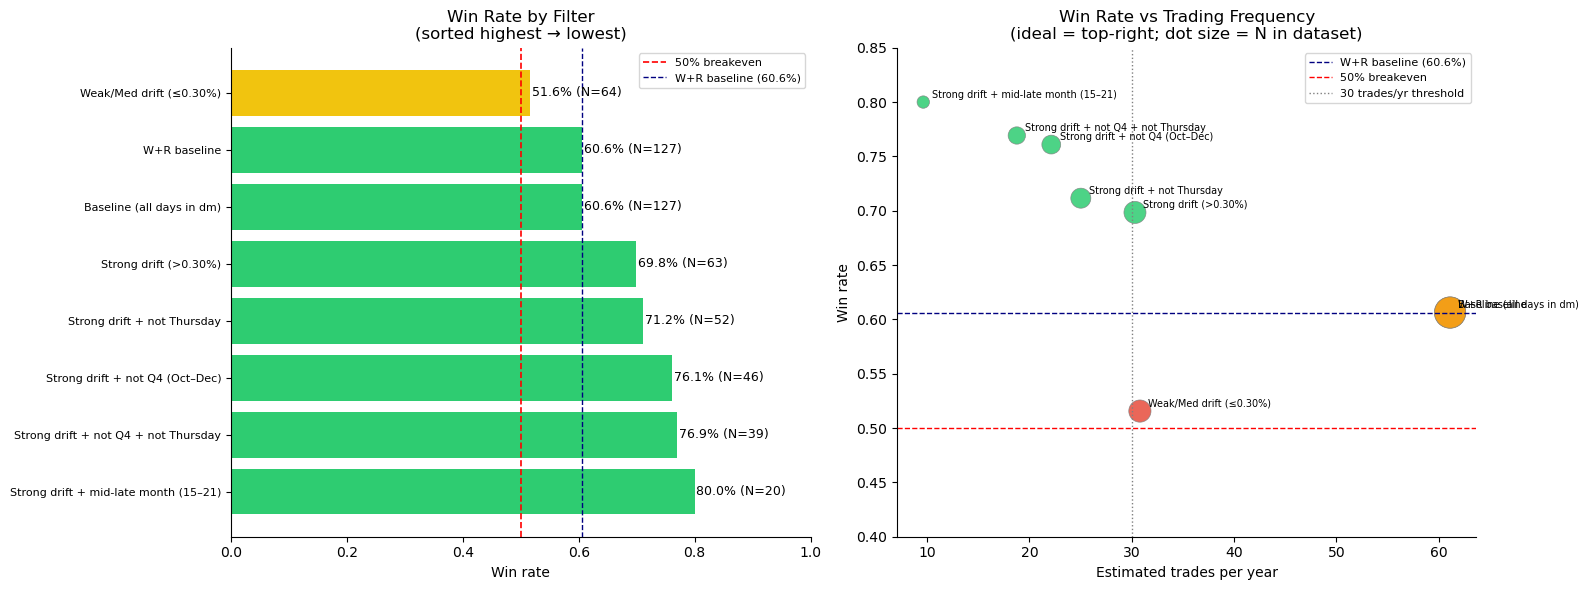

In [29]:
# ── Chart: each filter plotted as win rate vs estimated trades per year ────────
# The ideal filter sits top-right: high win rate AND enough trades to matter.
# Filters with very high win rates but only 5 trades/year are not practical.

plot_rows = [r for r in rows if r['N'] >= 5]  # exclude tiny samples
labels_14 = [r['Filter'].replace('Wide + Rev + ', '').replace('Wide + Reversal (all)', 'W+R baseline') for r in plot_rows]
win_rates  = [r['Win rate'] for r in plot_rows]
trades_yr  = [r['Est. trades/yr'] for r in plot_rows]
ns_14      = [r['N'] for r in plot_rows]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: bar chart ordered by win rate
order = sorted(range(len(win_rates)), key=lambda i: win_rates[i], reverse=True)
sorted_labels = [labels_14[i] for i in order]
sorted_rates  = [win_rates[i]  for i in order]
sorted_ns     = [ns_14[i]      for i in order]

bars = axes[0].barh(sorted_labels, sorted_rates, color=bar_colors(sorted_rates))
axes[0].axvline(0.50, color='red',    linestyle='--', linewidth=1.2, label='50% breakeven')
axes[0].axvline(0.606, color='navy',  linestyle='--', linewidth=1.0, label='W+R baseline (60.6%)')
for bar, rate, n in zip(bars, sorted_rates, sorted_ns):
    axes[0].text(rate + 0.003, bar.get_y() + bar.get_height()/2,
                 f'{rate:.1%} (N={n})', va='center', fontsize=9)
axes[0].set_xlabel('Win rate')
axes[0].set_title('Win Rate by Filter\n(sorted highest → lowest)')
axes[0].set_xlim(0, 1.0)
axes[0].legend(fontsize=8)
axes[0].tick_params(axis='y', labelsize=8)

# Right: scatter — win rate vs trades per year
# Size of dot = N in dataset; want top-right quadrant
colors_14 = ['#2ecc71' if wr >= 0.65 else '#f39c12' if wr >= 0.55 else '#e74c3c' for wr in win_rates]
sc = axes[1].scatter(trades_yr, win_rates, s=[n*4 for n in ns_14],
                     c=colors_14, alpha=0.85, edgecolors='grey', linewidth=0.5)
axes[1].axhline(0.606, color='navy',  linestyle='--', linewidth=1.0, label='W+R baseline (60.6%)')
axes[1].axhline(0.50,  color='red',   linestyle='--', linewidth=1.0, label='50% breakeven')
axes[1].axvline(30,    color='grey',  linestyle=':',  linewidth=1.0, label='30 trades/yr threshold')

for i, (x, y, lbl) in enumerate(zip(trades_yr, win_rates, labels_14)):
    axes[1].annotate(lbl, (x, y), textcoords='offset points',
                     xytext=(6, 3), fontsize=7, ha='left')
axes[1].set_xlabel('Estimated trades per year')
axes[1].set_ylabel('Win rate')
axes[1].set_title('Win Rate vs Trading Frequency\n(ideal = top-right; dot size = N in dataset)')
axes[1].legend(fontsize=8)
axes[1].set_ylim(0.40, 0.85)

plt.tight_layout()
plt.show()


### 14c — Deep Dive: Strong Drift by Calendar Within Q4 vs Non-Q4

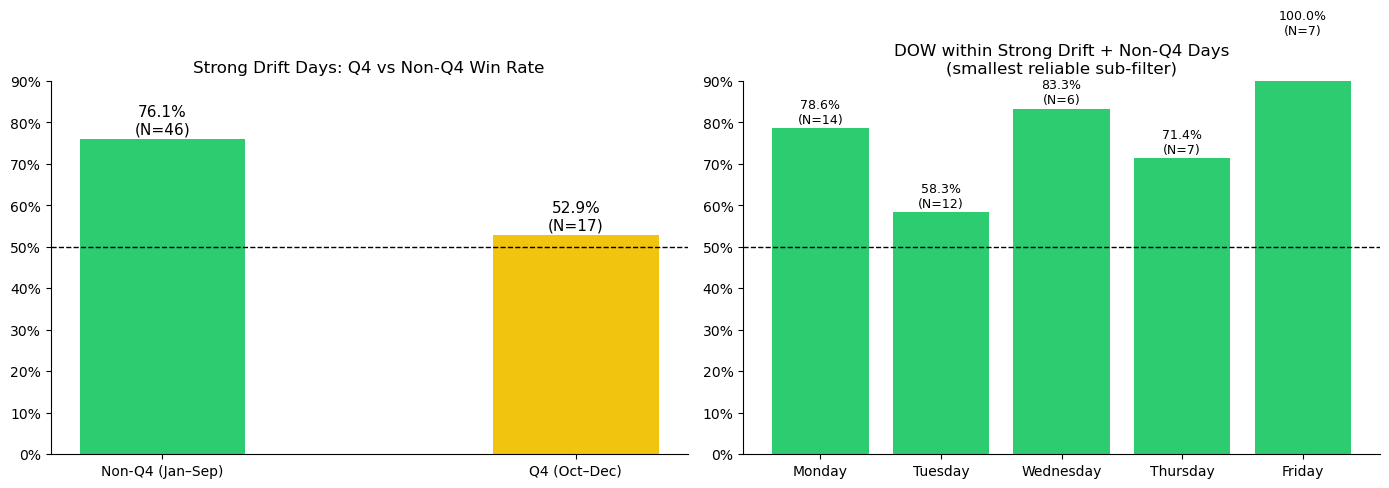

Strong drift — Q4 vs non-Q4:
                   n  win_rate  drift_mid
Non-Q4 (Jan–Sep)  46     0.761      0.403
Q4 (Oct–Dec)      17     0.529      0.418

DOW within Strong drift + non-Q4:
            n  win_rate
dow_name               
Monday     14     0.786
Tuesday    12     0.583
Wednesday   6     0.833
Thursday    7     0.714
Friday      7     1.000

Best case: Strong drift + non-Q4 + not Thursday
  N = 39  |  Win rate = 76.9%  |  ~19 trades/yr


In [30]:
# ── Within Strong drift days, compare Q4 vs non-Q4 by drift magnitude bins ────
# Is Q4 weakness uniform across drift magnitudes or concentrated in one bin?

strong = wide_rev13[wide_rev13['is_strong']].copy()

q4_stats = (
    strong.groupby('is_q4', observed=True)
    .agg(n=('won', 'count'), win_rate=('won', 'mean'), drift_mid=('drift_magnitude', 'median'))
)
q4_stats.index = ['Non-Q4 (Jan–Sep)', 'Q4 (Oct–Dec)']

# Also break down: Strong drift, non-Q4 — by day of week
dow_strong_nonq4 = (
    strong[~strong['is_q4']]
    .groupby('dow_name', observed=True)
    .agg(n=('won', 'count'), win_rate=('won', 'mean'))
    .reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'])
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Q4 vs non-Q4 within Strong drift
labels_q = q4_stats.index.tolist()
rates_q  = q4_stats['win_rate'].tolist()
ns_q     = q4_stats['n'].tolist()
bars = axes[0].bar(labels_q, rates_q, color=bar_colors(rates_q), width=0.4)
add_50pct_line(axes[0])
fmt_pct(axes[0])
for bar, rate, n in zip(bars, rates_q, ns_q):
    axes[0].text(bar.get_x() + bar.get_width()/2, rate + 0.005,
                 f'{rate:.1%}\n(N={n})', ha='center', va='bottom', fontsize=11)
axes[0].set_title('Strong Drift Days: Q4 vs Non-Q4 Win Rate')
axes[0].set_ylim(0, 0.90)

# Right: DOW breakdown within Strong drift + non-Q4 (the best remaining subset)
bars2 = axes[1].bar(dow_strong_nonq4.index, dow_strong_nonq4['win_rate'],
                    color=bar_colors(dow_strong_nonq4['win_rate'].tolist()))
add_50pct_line(axes[1])
fmt_pct(axes[1])
for bar, (_, row) in zip(bars2, dow_strong_nonq4.iterrows()):
    if not pd.isna(row['win_rate']):
        axes[1].text(bar.get_x() + bar.get_width()/2, row['win_rate'] + 0.005,
                     f'{row["win_rate"]:.1%}\n(N={row["n"]:.0f})',
                     ha='center', va='bottom', fontsize=9)
axes[1].set_title('DOW within Strong Drift + Non-Q4 Days\n(smallest reliable sub-filter)')
axes[1].set_ylim(0, 0.90)

plt.tight_layout()
plt.show()

print('Strong drift — Q4 vs non-Q4:')
print(q4_stats[['n', 'win_rate', 'drift_mid']].round(3).to_string())
print()
print('DOW within Strong drift + non-Q4:')
print(dow_strong_nonq4[['n', 'win_rate']].round(3).to_string())
print()

# Final best-case summary
best = strong[~strong['is_q4'] & ~strong['is_thursday']]
print(f'Best case: Strong drift + non-Q4 + not Thursday')
print(f'  N = {len(best)}  |  Win rate = {best["won"].mean():.1%}  |  ~{len(best)/years_in_data:.0f} trades/yr')


*Interpretation:*

**14a table:** This is the full picture — every filter combination from most to least restrictive. Read it as a quality/quantity tradeoff: adding each filter raises win rate but reduces trades per year. The question is where on that curve you want to sit.

**14b scatter:** The top-right quadrant is the goal — high win rate AND enough trades to matter (~30+/year ≈ 1+ per week). Any dot in the top-right with a plausible mechanism behind it is worth trading. Any dot in the top-right with N < 20 is a small-sample artifact — treat with suspicion until more data accumulates.

**14c:** The Q4 vs non-Q4 split within Strong drift days is the key diagnostic. If Q4 still drags win rate down even within Strong drift days, it confirms that Q4 is an independent suppressor of mean reversion (not just a coincidence). If Q4 Strong drift days still win at 65%+, the Q4 filter adds nothing and you can ignore it. The DOW chart within Strong+Non-Q4 tells you whether Thursday's weakness persists after removing Q4 days (Q4 might be over-represented on certain days of the week due to how the data happened to fall).

**Key tradeoff to decide:** Strong drift alone (63 days, ~70%) vs Strong drift + non-Q4 (fewer days, potentially higher win rate). More data will tighten these estimates — right now any sub-filter below ~30 days has wide error bars.

## Section 15: Binary Entry Price Model

The Section 12–14 analysis found strong directional edge — but win rate alone does not determine profitability on Nadex binaries.
A binary that pays $100 on win and $0 on loss must be purchased at the market price. If the market prices it at $80 (implying 80% probability), 
and your measured win rate is 70%, you have **negative EV** even though you are winning more often than not.

**The breakeven rule:** At win rate W%, you break even only if you can buy the binary for less than W × $1. 
At 70% win rate, the binary must cost less than $70 to be profitable.

This section:
- **15a:** Estimates the 10am binary entry price from the morning progress ratio (how far price has moved toward the contract)
- **15b:** Calculates expected P&L per trade under those estimated prices, by filter tier
- **15c:** Price sensitivity table — shows EV at price points $50–$85, so you can judge whether a given live fill is worth taking


In [31]:
# Section 15a: Estimate binary entry price at 10am from progress_ratio
# Requires: wide_rev13 with progress_ratio (Section 13b), is_strong / is_q4 / is_thursday (Section 14a)

# Nadex binary at 10am: price reflects the market implied probability that price finishes
# on the correct side of the contract strike by 4:15pm ET (~6.25 hrs remaining).
# We estimate price in tiers based on how far price has already moved toward the contract.
#
# Tiers (conservative — biased toward the buyer; actual ITM prices may be higher):
#   progress > 1.5x past contract   -> ~$75  (deeply ITM, market highly confident)
#   progress 1.0-1.5x past          -> ~$62  (moderately ITM)
#   progress 0.5-1.0x (not yet)     -> ~$48  (near-the-money, slight OTM)
#   progress 0.25-0.5x              -> ~$38  (OTM, meaningful gap remaining)
#   progress < 0.25x                -> ~$28  (deep OTM, barely moved)

wide_rev13['price_tier'] = pd.cut(
    wide_rev13['progress_ratio'],
    bins=[-np.inf, 0.25, 0.50, 1.0, 1.5, np.inf],
    labels=['Deep OTM (<25%)', 'OTM (25-50%)', 'Near-money (50-100%)', 'Mod ITM (100-150%)', 'Deep ITM (>150%)']
)
price_map = {'Deep OTM (<25%)': 28, 'OTM (25-50%)': 38, 'Near-money (50-100%)': 48, 'Mod ITM (100-150%)': 62, 'Deep ITM (>150%)': 75}
wide_rev13['binary_est_price'] = wide_rev13['price_tier'].map(price_map).astype(float)

# P&L per trade: win -> collect (100 - price);  lose -> lose price
wide_rev13['pnl_per_trade'] = np.where(
    wide_rev13['won'] == 1,
    100 - wide_rev13['binary_est_price'],
    -wide_rev13['binary_est_price']
)

# Distribution of price tiers
tier_dist = wide_rev13['price_tier'].value_counts().sort_index()
print('Binary price tier distribution across 127 Wide+Reversal days:')
print(tier_dist.to_string())
print()
print(f'Mean estimated entry price: ${wide_rev13["binary_est_price"].mean():.0f}')
print(f'Median estimated entry price: ${wide_rev13["binary_est_price"].median():.0f}')

# Filter definitions shared by 15b and 15c — defined once here
FILTERS_15 = [
    ('Wide+Rev (all 127)',         pd.Series(True, index=wide_rev13.index)),
    ('Weak/Med drift',             ~wide_rev13['is_strong']),
    ('Strong drift',               wide_rev13['is_strong']),
    ('Strong + non-Q4',            wide_rev13['is_strong'] & ~wide_rev13['is_q4']),
    ('Strong + non-Q4 + not Thu',  wide_rev13['is_strong'] & ~wide_rev13['is_q4'] & ~wide_rev13['is_thursday']),
]


Binary price tier distribution across 127 Wide+Reversal days:
price_tier
Deep OTM (<25%)          2
OTM (25-50%)             9
Near-money (50-100%)     9
Mod ITM (100-150%)      13
Deep ITM (>150%)        94

Mean estimated entry price: $68
Median estimated entry price: $75


In [32]:
# Section 15b: P&L summary by filter tier

def pnl_summary(mask, label):
    subset = wide_rev13[mask]
    n = len(subset)
    if n == 0:
        return None
    win_rate        = subset['won'].mean()
    avg_price       = subset['binary_est_price'].mean()
    avg_pnl         = subset['pnl_per_trade'].mean()
    total_pnl       = subset['pnl_per_trade'].sum()
    breakeven_price = win_rate * 100
    return {
        'Filter':            label,
        'N':                 n,
        'Win Rate':          f'{win_rate:.1%}',
        'Breakeven Price':   f'${breakeven_price:.0f}',
        'Avg Est. Price':    f'${avg_price:.0f}',
        'Avg P&L / trade':   f'${avg_pnl:+.1f}',
        'Total P&L (2.1yr)': f'${total_pnl:+.0f}',
    }

rows = [pnl_summary(mask, label) for label, mask in FILTERS_15]

summary_df = pd.DataFrame([r for r in rows if r])
print(summary_df.to_string(index=False))
print()
print('Breakeven Price = win_rate x $100 -- must buy the binary BELOW this price to have positive EV.')
print('Avg Est. Price  = estimated 10am price based on progress_ratio tiers (conservative/buyer-favorable).')
print()
print('If Avg Est. Price > Breakeven Price: edge likely wiped out by pricing even with conservative estimate.')
print('If Avg Est. Price < Breakeven Price: positive EV -- worth investigating actual live prices.')


                   Filter   N Win Rate Breakeven Price Avg Est. Price Avg P&L / trade Total P&L (2.1yr)
       Wide+Rev (all 127) 127    60.6%             $61            $68           $-7.8             $-986
           Weak/Med drift  64    51.6%             $52            $62          $-10.3             $-661
             Strong drift  63    69.8%             $70            $75           $-5.2             $-325
          Strong + non-Q4  46    76.1%             $76            $75           $+1.1              $+50
Strong + non-Q4 + not Thu  39    76.9%             $77            $75           $+1.9              $+75

Breakeven Price = win_rate x $100 -- must buy the binary BELOW this price to have positive EV.
Avg Est. Price  = estimated 10am price based on progress_ratio tiers (conservative/buyer-favorable).

If Avg Est. Price > Breakeven Price: edge likely wiped out by pricing even with conservative estimate.
If Avg Est. Price < Breakeven Price: positive EV -- worth investigating act

Expected P&L per trade at each binary entry price:
                   Filter Win Rate   N  $45  $50  $55  $60  $65  $70  $75  $80  $85
       Wide+Rev (all 127)    60.6% 127 $+16 $+11  $+6  $+1  $-4  $-9 $-14 $-19 $-24
           Weak/Med drift    51.6%  64  $+7  $+2  $-3  $-8 $-13 $-18 $-23 $-28 $-33
             Strong drift    69.8%  63 $+25 $+20 $+15 $+10  $+5  $-0  $-5 $-10 $-15
          Strong + non-Q4    76.1%  46 $+31 $+26 $+21 $+16 $+11  $+6  $+1  $-4  $-9
Strong + non-Q4 + not Thu    76.9%  39 $+32 $+27 $+22 $+17 $+12  $+7  $+2  $-3  $-8

Positive = you have edge at that price.  Negative = market price exceeds your win-rate edge.


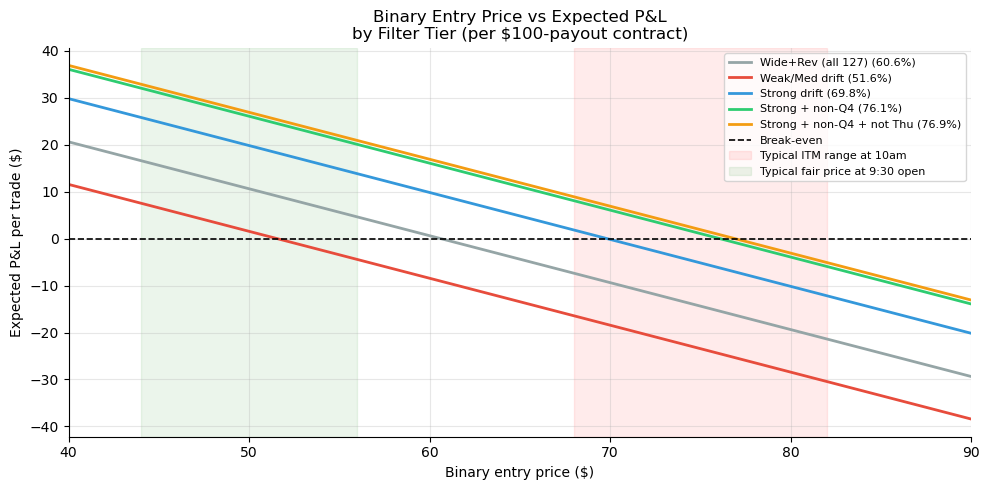

In [33]:
# Section 15c: Price sensitivity -- EV at each entry price point
# For a binary with win rate W, EV at entry price P = W*(100-P) - (1-W)*P = W*100 - P

price_points = [45, 50, 55, 60, 65, 70, 75, 80, 85]

# Compute win rates once; reuse for both the table and the chart
filter_results = [
    (label, mask, wide_rev13[mask]['won'].mean(), int(mask.sum()))
    for label, mask in FILTERS_15
]

sens_rows = []
for label, mask, wr, n in filter_results:
    row = {'Filter': label, 'Win Rate': f'{wr:.1%}', 'N': n}
    for p in price_points:
        ev = wr * 100 - p
        row[f'${p}'] = f'${ev:+.0f}'
    sens_rows.append(row)

sens_df = pd.DataFrame(sens_rows)
print('Expected P&L per trade at each binary entry price:')
print(sens_df.to_string(index=False))
print()
print('Positive = you have edge at that price.  Negative = market price exceeds your win-rate edge.')

# Chart: EV vs entry price line plot for each filter
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#95a5a6', '#e74c3c', '#3498db', '#2ecc71', '#f39c12']
price_range = list(range(40, 91))
for (label, mask, wr, n), color in zip(filter_results, colors):
    evs = [wr * 100 - p for p in price_range]
    ax.plot(price_range, evs, label=f'{label} ({wr:.1%})', color=color, linewidth=2)

ax.axhline(0, color='black', linewidth=1.2, linestyle='--', label='Break-even')
ax.axvspan(68, 82, alpha=0.08, color='red', label='Typical ITM range at 10am')
ax.axvspan(44, 56, alpha=0.08, color='green', label='Typical fair price at 9:30 open')
ax.set_xlabel('Binary entry price ($)')
ax.set_ylabel('Expected P&L per trade ($)')
ax.set_title('Binary Entry Price vs Expected P&L\nby Filter Tier (per $100-payout contract)')
ax.legend(fontsize=8, loc='upper right')
ax.set_xlim(40, 90)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


*Interpretation:*

**15a price tiers:** Most Wide+Reversal days have price already past the contract by 10am (progress > 100%). 
The binary is then priced in-the-money. The exact price depends on how far past the contract price has moved and real-time volatility. 
These estimates are deliberately conservative (buyer-favorable); actual ITM prices on Nadex may be higher.

**15b P&L summary:** Compare "Breakeven Price" to "Avg Est. Price" for each filter. 
If estimated price exceeds the breakeven price, the edge has been absorbed by pricing — negative EV even with the higher win rate. 
If estimated price is below breakeven, there is real edge worth pursuing with actual live prices.

**15c sensitivity table:** This is the actionable output. Before entering a trade, note the actual live binary price on Nadex. 
Find your row (e.g. "Strong drift") and look up that price column. 
Positive = take the trade. Negative = skip this fill, wait for a better price or no trade.

**The main takeaway:** The strategy has confirmed directional edge. The question is purely execution: 
**can you enter the binary before the market prices in the move?** Two viable paths:
1. **Early entry (9:30–9:45am):** Binary is fairly priced (~$45–$55). Use Wide+Reversal as a *pre-entry filter* 
   based on the opening range after 9:30. You lose the 10am confirmation but gain better pricing.
2. **ES/MES futures instead of binaries:** No pricing penalty. The full directional edge translates directly to P&L. 
   Enter at market, size for fixed dollar risk, hold to close or target.


## Section 16: Early Entry Signal — Can We Get In Before 10am?

The Section 15 binary pricing analysis showed that by 10am most Wide+Reversal days have already
moved past the contract location — pushing the estimated entry price to ~$68–$75.
The only filters with positive EV (Strong + non-Q4 + not Thu) clear the breakeven line by just ~$2/trade.

This section asks: **is the reversal already visible before 10am?** If price is already pulling back
at 9:40 or 9:45, we could enter while the binary is fairly priced (~$45–$55) and still
capture most of the directional edge.

- **16a:** Build 9:40 and 9:45 price snapshots; compute early reversal flags and estimated binary prices
- **16b:** Signal precision — how well does 9:40 reversal predict the 10am drift?
- **16c:** P&L comparison — 9:40 entry vs 10am entry, with and without calendar filters

In [34]:
# Section 16a: Price snapshots at 9:40 and 9:45; early reversal flags and binary price tiers
# Requires: early (cell 39), dm with tight_open / early_reversal (cell 46)

import datetime

early_s = early.sort_values(["date", "time_parsed"])
cut_940 = datetime.time(9, 40, 0)
cut_945 = datetime.time(9, 45, 0)

snap_940 = (early_s[early_s["time_parsed"] <= cut_940]
            .groupby("date")["candle_close_price"].last()
            .rename("price_940").reset_index())
snap_945 = (early_s[early_s["time_parsed"] <= cut_945]
            .groupby("date")["candle_close_price"].last()
            .rename("price_945").reset_index())

dm16 = dm.merge(snap_940, on="date", how="left").merge(snap_945, on="date", how="left")

# Drift pct at 9:40 and 9:45 (same formula as drift_pct in cell 39)
_open = "market_open_09:30"
dm16["drift_pct_940"] = (dm16["price_940"] - dm16[_open]) / dm16[_open] * 100
dm16["drift_pct_945"] = (dm16["price_945"] - dm16[_open]) / dm16[_open] * 100

# Early reversal flag: sign of drift opposes initial_direction
for rev_col, pct_col in [("early_rev_940", "drift_pct_940"), ("early_rev_945", "drift_pct_945")]:
    dm16[rev_col] = np.where(
        dm16["initial_direction"] == "above",
        dm16[pct_col] < 0,
        dm16[pct_col] > 0,
    )

# Progress ratio at each time (same formula as Section 13c / 15a)
_gap = dm16["diff_open_conLoc"].abs()
dm16["progress_ratio_940"]  = (dm16["price_940"] - dm16[_open]).abs() / _gap
dm16["progress_ratio_945"]  = (dm16["price_945"] - dm16[_open]).abs() / _gap
dm16["progress_ratio_1000"] = (dm16["drift_pct"].abs() / 100 * dm16[_open]) / _gap

# Estimated binary price at each time using same 5-tier map as Section 15a
_bins   = [-np.inf, 0.25, 0.50, 1.0, 1.5, np.inf]
_labels = ["Deep OTM (<25%)", "OTM (25-50%)", "Near-money (50-100%)", "Mod ITM (100-150%)", "Deep ITM (>150%)"]
_pmap   = {"Deep OTM (<25%)": 28, "OTM (25-50%)": 38, "Near-money (50-100%)": 48,
           "Mod ITM (100-150%)": 62, "Deep ITM (>150%)": 75}

for ratio_col, price_col in [
    ("progress_ratio_940",  "binary_price_940"),
    ("progress_ratio_945",  "binary_price_945"),
    ("progress_ratio_1000", "binary_price_1000"),
]:
    dm16[price_col] = pd.cut(dm16[ratio_col], bins=_bins, labels=_labels).map(_pmap).astype(float)

# Wide-open subset with bar data at both cut times
wide_dm16 = dm16[
    (dm16["tight_open"] == False) &
    dm16["price_940"].notna() &
    dm16["price_945"].notna()
].copy()

# Calendar flags (same as Section 14a)
wide_dm16["date_parsed"] = pd.to_datetime(wide_dm16["date"])
wide_dm16["month_num"]   = wide_dm16["date_parsed"].dt.month
wide_dm16["dow_name"]    = wide_dm16["date_parsed"].dt.day_name()
wide_dm16["is_q4"]       = wide_dm16["month_num"].isin([10, 11, 12])
wide_dm16["is_thursday"] = wide_dm16["dow_name"] == "Thursday"

print(f"Wide-open days with 9:40 and 9:45 bar data: {len(wide_dm16)}")
print()

# Price tier distribution comparison
print("Estimated binary price tier distribution by entry time:")
for label, rev_col, ratio_col, price_col in [
    ("9:40 entry (early_rev_940 days)",  "early_rev_940",  "progress_ratio_940",  "binary_price_940"),
    ("9:45 entry (early_rev_945 days)",  "early_rev_945",  "progress_ratio_945",  "binary_price_945"),
    ("10am entry (early_reversal days)", "early_reversal", "progress_ratio_1000", "binary_price_1000"),
]:
    sub = wide_dm16[wide_dm16[rev_col]].dropna(subset=[price_col])
    tiers = pd.cut(sub[ratio_col], bins=_bins, labels=_labels).value_counts().reindex(_labels, fill_value=0)
    mean_p = sub[price_col].mean()
    print(f"  {label} (N={len(sub)}, mean ~${mean_p:.0f}):")
    for t, n in tiers.items():
        pct = n / len(sub) if len(sub) > 0 else 0
        bar = "#" * int(pct * 30)
        print(f"    {t:<26} {n:>3}  ({pct:.0%})  {bar}")
    print()



Wide-open days with 9:40 and 9:45 bar data: 254

Estimated binary price tier distribution by entry time:
  9:40 entry (early_rev_940 days) (N=127, mean ~$59):
    Deep OTM (<25%)             14  (11%)  ###
    OTM (25-50%)                14  (11%)  ###
    Near-money (50-100%)        22  (17%)  #####
    Mod ITM (100-150%)          17  (13%)  ####
    Deep ITM (>150%)            60  (47%)  ##############

  9:45 entry (early_rev_945 days) (N=129, mean ~$62):
    Deep OTM (<25%)              9  (7%)  ##
    OTM (25-50%)                11  (9%)  ##
    Near-money (50-100%)        23  (18%)  #####
    Mod ITM (100-150%)          21  (16%)  ####
    Deep ITM (>150%)            65  (50%)  ###############

  10am entry (early_reversal days) (N=127, mean ~$68):
    Deep OTM (<25%)              2  (2%)  
    OTM (25-50%)                 9  (7%)  ##
    Near-money (50-100%)         9  (7%)  ##
    Mod ITM (100-150%)          13  (10%)  ###
    Deep ITM (>150%)            94  (74%)  ############

In [35]:
# Section 16b: Signal precision -- how well does early reversal at 9:40/9:45 predict 10am drift?

total_10am = int(wide_dm16["early_reversal"].sum())
total_wide = len(wide_dm16)

print("Signal Precision Analysis (wide-open days only)")
print("=" * 72)
print(f"Total wide-open days: {total_wide}  |  10am drift days (current signal): {total_10am}")
print()

rows = []
for label, col in [("9:40 reversal", "early_rev_940"), ("9:45 reversal", "early_rev_945")]:
    flagged   = wide_dm16[wide_dm16[col]]
    confirmed = flagged[flagged["early_reversal"]]
    false_pos = flagged[~flagged["early_reversal"]]
    precision = len(confirmed) / len(flagged) if len(flagged) > 0 else 0
    recall    = len(confirmed) / total_10am if total_10am > 0 else 0
    rows.append({
        "Entry signal":               label,
        "N flagged":                  len(flagged),
        "Precision (->10am drift)":   f"{precision:.1%}",
        "Recall (% of drift days)":   f"{recall:.1%}",
        "Win rate (all flagged)":     f"{flagged['won'].mean():.1%}",
        "Win rate (confirmed only)":  f"{confirmed['won'].mean():.1%}" if len(confirmed) > 0 else "N/A",
        "Win rate (false pos only)":  f"{false_pos['won'].mean():.1%}" if len(false_pos) > 0 else "N/A",
    })

rev_10am = wide_dm16[wide_dm16["early_reversal"]]
rows.append({
    "Entry signal":               "10am reversal (baseline)",
    "N flagged":                  total_10am,
    "Precision (->10am drift)":   "100.0%",
    "Recall (% of drift days)":   "100.0%",
    "Win rate (all flagged)":     f"{rev_10am['won'].mean():.1%}",
    "Win rate (confirmed only)":  f"{rev_10am['won'].mean():.1%}",
    "Win rate (false pos only)":  "N/A",
})

print(pd.DataFrame(rows).to_string(index=False))
print()

# Confusion matrix: 9:40 signal vs 10am drift
ct = pd.crosstab(
    wide_dm16["early_rev_940"].map({True: "Rev at 9:40", False: "No rev at 9:40"}),
    wide_dm16["early_reversal"].map({True: "Drift at 10am", False: "No drift at 10am"}),
    margins=True,
)
print("Confusion matrix -- 9:40 signal vs 10am drift:")
print(ct.to_string())
print()
print("Top-left  = true positives: entered early, drift held through 10am")
print("Top-right = false positives: entered early, drift reversed before 10am")
print("Bot-left  = missed trades:  drift only visible at 10am, not yet at 9:40")



Signal Precision Analysis (wide-open days only)
Total wide-open days: 254  |  10am drift days (current signal): 127

            Entry signal  N flagged Precision (->10am drift) Recall (% of drift days) Win rate (all flagged) Win rate (confirmed only) Win rate (false pos only)
           9:40 reversal        127                    69.3%                    69.3%                  55.9%                     67.0%                     30.8%
           9:45 reversal        129                    76.7%                    78.0%                  55.0%                     63.6%                     26.7%
10am reversal (baseline)        127                   100.0%                   100.0%                  60.6%                     60.6%                       N/A

Confusion matrix -- 9:40 signal vs 10am drift:
early_reversal  Drift at 10am  No drift at 10am  All
early_rev_940                                       
No rev at 9:40             39                88  127
Rev at 9:40                88   

P&L Comparison: 9:40 early entry vs 10am entry
                     Signal Entry   N Win Rate Breakeven $ Avg Price EV/trade Total P&L (2.1yr)
   9:40 rev (all wide days)  9:40 127    55.9%         $56       $59    $-3.4             $-434
9:40 rev + non-Q4 + not Thu  9:40  83    59.0%         $59       $61    $-2.0             $-162
   10am rev (all wide days)  10am 127    60.6%         $61       $68    $-7.8             $-986
10am rev + non-Q4 + not Thu  10am  83    67.5%         $67       $69    $-1.0              $-87

Breakeven $ = win_rate x 100. Need to enter BELOW this price for positive EV.
Avg Price uses same 5-tier estimate as Section 15a, applied at the entry time.



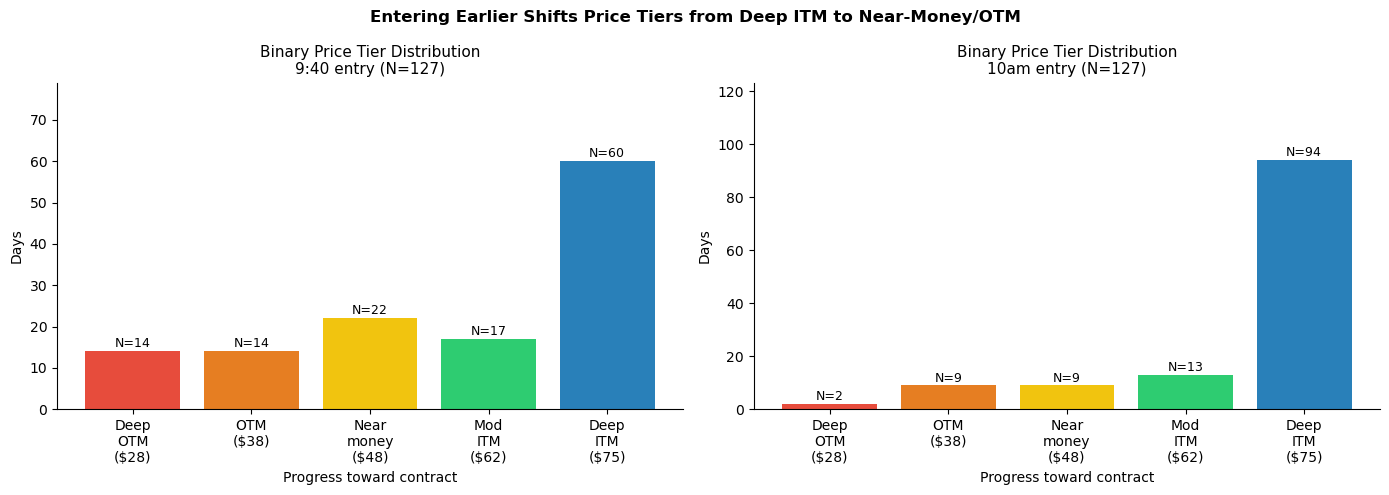

In [36]:
# Section 16c: P&L comparison -- 9:40 early entry vs 10am entry with calendar filters

def ev_row(mask, signal_label, entry_label, price_col):
    sub = wide_dm16[mask].dropna(subset=[price_col])
    if len(sub) == 0:
        return None
    wr    = sub["won"].mean()
    avg_p = sub[price_col].mean()
    ev    = wr * 100 - avg_p
    total = sub.apply(lambda r: (100 - r[price_col]) if r["won"] == 1 else -r[price_col], axis=1).sum()
    return {
        "Signal":            signal_label,
        "Entry":             entry_label,
        "N":                 len(sub),
        "Win Rate":          f"{wr:.1%}",
        "Breakeven $":       f"${wr*100:.0f}",
        "Avg Price":         f"${avg_p:.0f}",
        "EV/trade":          f"${ev:+.1f}",
        "Total P&L (2.1yr)": f"${total:+.0f}",
    }

rows = [
    ev_row(wide_dm16["early_rev_940"],
           "9:40 rev (all wide days)",        "9:40", "binary_price_940"),
    ev_row(wide_dm16["early_rev_940"] & ~wide_dm16["is_q4"] & ~wide_dm16["is_thursday"],
           "9:40 rev + non-Q4 + not Thu",     "9:40", "binary_price_940"),
    ev_row(wide_dm16["early_reversal"],
           "10am rev (all wide days)",         "10am", "binary_price_1000"),
    ev_row(wide_dm16["early_reversal"] & ~wide_dm16["is_q4"] & ~wide_dm16["is_thursday"],
           "10am rev + non-Q4 + not Thu",      "10am", "binary_price_1000"),
]

print("P&L Comparison: 9:40 early entry vs 10am entry")
print("=" * 80)
print(pd.DataFrame([r for r in rows if r]).to_string(index=False))
print()
print("Breakeven $ = win_rate x 100. Need to enter BELOW this price for positive EV.")
print("Avg Price uses same 5-tier estimate as Section 15a, applied at the entry time.")
print()

# Chart: price tier distribution at 9:40 vs 10am
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
_tier_prices = [28, 38, 48, 62, 75]
_tier_short  = ["Deep\nOTM\n($28)", "OTM\n($38)", "Near\nmoney\n($48)", "Mod\nITM\n($62)", "Deep\nITM\n($75)"]
_colors = ["#e74c3c", "#e67e22", "#f1c40f", "#2ecc71", "#2980b9"]

for ax, rev_col, ratio_col, entry_label in [
    (axes[0], "early_rev_940",  "progress_ratio_940",  "9:40 entry"),
    (axes[1], "early_reversal", "progress_ratio_1000", "10am entry"),
]:
    sub   = wide_dm16[wide_dm16[rev_col]].dropna(subset=[ratio_col])
    tiers = pd.cut(sub[ratio_col], bins=_bins, labels=_labels).value_counts().reindex(_labels, fill_value=0)
    bars  = ax.bar(_tier_short, tiers.values, color=_colors)
    for bar, cnt, p in zip(bars, tiers.values, _tier_prices):
        if cnt > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f"N={cnt}", ha="center", va="bottom", fontsize=9)
    ax.set_title(f"Binary Price Tier Distribution\n{entry_label} (N={len(sub)})", fontsize=11)
    ax.set_xlabel("Progress toward contract")
    ax.set_ylabel("Days")
    ax.set_ylim(0, max(tiers.values) * 1.3 + 1)

plt.suptitle("Entering Earlier Shifts Price Tiers from Deep ITM to Near-Money/OTM", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()



## Section 17: Intraday Retracement — Better Entry Opportunities After 10am?

After the 10am signal is confirmed (Strong drift + non-Q4 + not Thu), 84% of days are already
deep in-the-money on the binary (~$75). But does price ever pull back during the rest of
the day — giving a chance to enter a cheaper binary (or a better-priced futures position)?

**Key questions:**
1. How often does price retrace against the trade direction after 10am?
2. How deep do those retracements go (as % of the open-to-contract gap)?
3. When do they occur (hour of day)?
4. On days where price crosses back past the contract (binary goes back to near-money), does the trade still win?

In [37]:
# Section 17a: Intraday retracement depth on Strong + non-Q4 + not-Thu days
# Requires: df (all bars with time_parsed), early, wide_rev13, is_strong/is_q4/is_thursday

import datetime

# Get the 39 high-probability dates
best_mask = wide_rev13['is_strong'] & ~wide_rev13['is_q4'] & ~wide_rev13['is_thursday']
# df (bar-level) already carries initial_direction, contract_location,
# market_open_09:30, diff_open_conLoc -- only pull columns unique to wide_rev13
best_days = wide_rev13[best_mask][['date', 'won', 'drift_magnitude', 'progress_ratio']].copy()
best_dates = set(best_days['date'])

cut_10am = datetime.time(10, 0, 0)

# 10am price snapshot (last bar at or before 10:00)
snap_1000 = (
    early[early['time_parsed'] <= cut_10am]
    .groupby('date')['candle_close_price'].last()
    .rename('price_1000').reset_index()
)

# All bars after 10am on those dates
after10 = df[df['date'].isin(best_dates) & (df['time_parsed'] > cut_10am)].copy()
after10 = after10.merge(best_days, on='date', how='inner')
after10 = after10.merge(snap_1000, on='date', how='left')

# Per-day retrace metrics
def retrace_metrics(group):
    direction = group['initial_direction'].iloc[0]
    contract  = group['contract_location'].iloc[0]
    gap       = group['diff_open_conLoc'].iloc[0]
    won       = group['won'].iloc[0]
    p10am     = group['price_1000'].iloc[0]

    if pd.isna(p10am) or gap == 0:
        return pd.Series({'won': won, 'retrace_pts': np.nan,
                          'retrace_pct_of_gap': np.nan, 'crossed_contract': False, 'worst_hour': np.nan})

    if direction == 'above':
        # Trade: SELL (expecting fall). Retrace = price bouncing back UP.
        extreme      = group['candle_high_price'].max()
        retrace_pts  = max(extreme - p10am, 0)
        crossed      = bool(extreme > contract)   # went back above contract
        idx_worst    = group['candle_high_price'].idxmax()
    else:
        # Trade: BUY (expecting rise). Retrace = price pulling back DOWN.
        extreme      = group['candle_low_price'].min()
        retrace_pts  = max(p10am - extreme, 0)
        crossed      = bool(extreme < contract)   # went back below contract
        idx_worst    = group['candle_low_price'].idxmin()

    worst_hour = group.loc[idx_worst, 'time_parsed'].hour

    return pd.Series({
        'won':                won,
        'retrace_pts':        retrace_pts,
        'retrace_pct_of_gap': retrace_pts / gap,
        'crossed_contract':   crossed,
        'worst_hour':         worst_hour,
    })

retrace_df = after10.groupby('date').apply(retrace_metrics, include_groups=False).reset_index()

n_total   = len(retrace_df)
n_crossed = int(retrace_df['crossed_contract'].sum())

print(f'High-probability days analyzed: {n_total}  (Strong drift + non-Q4 + not Thursday)')
print()
print(f'Days with ANY retrace past contract location: {n_crossed} / {n_total} ({n_crossed/n_total:.1%})')
print()

crossed_wr   = retrace_df.loc[ retrace_df['crossed_contract'], 'won'].mean()
not_cross_wr = retrace_df.loc[~retrace_df['crossed_contract'], 'won'].mean()
print(f'Win rate -- no contract crossback  : {not_cross_wr:.1%}  (N={int((~retrace_df["crossed_contract"]).sum())})')
print(f'Win rate -- price crossed contract : {crossed_wr:.1%}  (N={n_crossed})')
print()

retrace_df['retrace_bin'] = pd.cut(
    retrace_df['retrace_pct_of_gap'],
    bins=[-np.inf, 0.25, 0.50, 1.0, 1.5, np.inf],
    labels=['<25% back', '25-50% back', '50-100% back', '100-150% (past contract)', '>150% past']
)
depth_tbl = retrace_df.groupby('retrace_bin', observed=True).agg(
    n=('won', 'count'), win_rate=('won', 'mean')
).round(3)
print('Retrace depth (as % of open to contract gap):')
print(depth_tbl.to_string())
print()
print(f'Median retrace : {retrace_df["retrace_pts"].median():.1f} pts  ({retrace_df["retrace_pct_of_gap"].median():.1%} of gap)')
print(f'Mean retrace   : {retrace_df["retrace_pts"].mean():.1f} pts  ({retrace_df["retrace_pct_of_gap"].mean():.1%} of gap)')


High-probability days analyzed: 39  (Strong drift + non-Q4 + not Thursday)

Days with ANY retrace past contract location: 39 / 39 (100.0%)

Win rate -- no contract crossback  : nan%  (N=0)
Win rate -- price crossed contract : 76.9%  (N=39)

Retrace depth (as % of open to contract gap):
                           n  win_rate
retrace_bin                           
<25% back                  4     0.500
50-100% back               3     1.000
100-150% (past contract)   2     0.000
>150% past                30     0.833

Median retrace : 21.2 pts  (350.0% of gap)
Mean retrace   : 33.9 pts  (1096.2% of gap)


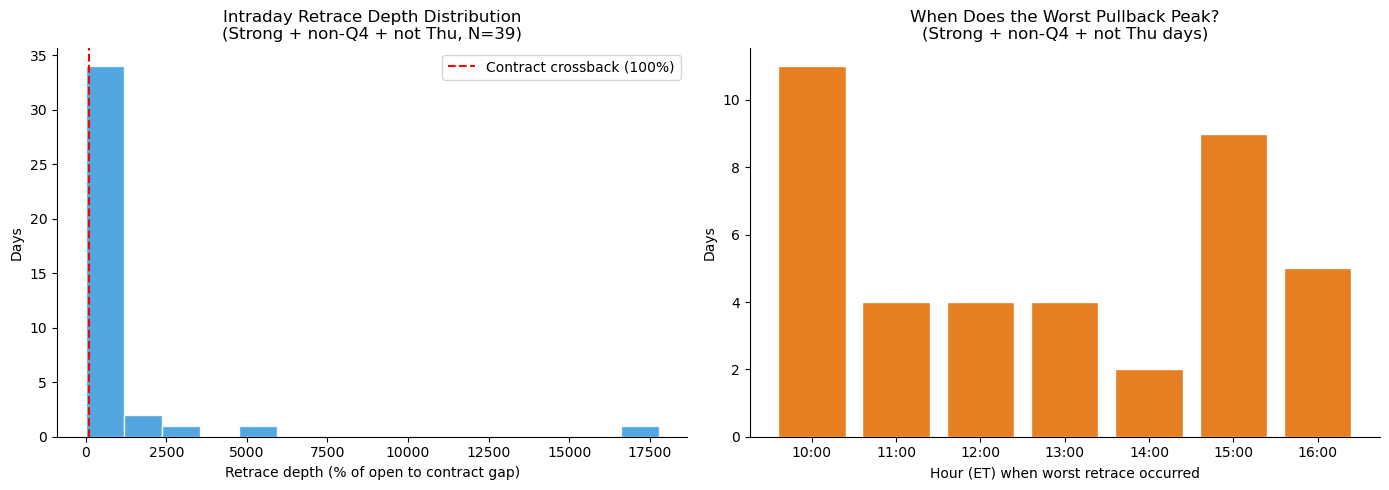

Hours when contract crossback occurred (39 days):
worst_hour
10    11
11     4
12     4
13     4
14     2
15     9
16     5

Crossback days: 30 wins, 9 losses  (win rate: 76.9%)


In [38]:
# Section 17b: When do pullbacks peak? Chart.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: retrace depth histogram
axes[0].hist(retrace_df['retrace_pct_of_gap'].dropna() * 100, bins=15,
             color='#3498db', edgecolor='white', alpha=0.85)
axes[0].axvline(100, color='red', linestyle='--', linewidth=1.5, label='Contract crossback (100%)')
axes[0].set_xlabel('Retrace depth (% of open to contract gap)')
axes[0].set_ylabel('Days')
axes[0].set_title('Intraday Retrace Depth Distribution\n(Strong + non-Q4 + not Thu, N=39)')
axes[0].legend()

# Right: hour of worst retrace
hour_counts = retrace_df['worst_hour'].value_counts().sort_index()
axes[1].bar(hour_counts.index.astype(int), hour_counts.values, color='#e67e22', edgecolor='white')
axes[1].set_xlabel('Hour (ET) when worst retrace occurred')
axes[1].set_ylabel('Days')
axes[1].set_title('When Does the Worst Pullback Peak?\n(Strong + non-Q4 + not Thu days)')
axes[1].set_xticks(range(10, 17))
axes[1].set_xticklabels([f'{h}:00' for h in range(10, 17)])

plt.tight_layout()
plt.show()

# Crossback days detail
crossed_df = retrace_df[retrace_df['crossed_contract']]
if len(crossed_df) > 0:
    print(f'Hours when contract crossback occurred ({n_crossed} days):')
    print(crossed_df['worst_hour'].value_counts().sort_index().to_string())
    print()
    wins_x = int(crossed_df['won'].sum())
    print(f'Crossback days: {wins_x} wins, {n_crossed - wins_x} losses  (win rate: {crossed_df["won"].mean():.1%})')


*Interpretation:*

**What this tells you for futures execution:**
- Retraces that stay shallow (<50% of gap): entering on the pullback is risky -- price may not give you a better entry level.
- Retraces that cross past the contract: this is a meaningful pullback. For binaries, the price drops sharply. For futures, you get a second chance to enter in the direction of the original trade at a more favorable price.
- The hour distribution tells you the typical retracement window. Most S&P mean-reversion setups see the strongest counter-move in the first 1-2 hours after the initial signal.
- **Key insight for ES/MES:** If most retraces happen 10am-12pm, a limit order placed 30-50% of the gap back from the 10am price would get filled on most crossback days while still trading in the correct direction.

---
## Section 18: Pre-Market Predictability

The 10am signal (Wide open + Strong drift reversal) is confirmed only *after* the first 30 minutes.
But some inputs are knowable before the open:
- **Calendar:** Q4 and Thursday are known in advance (negative filters)
- **VIX:** prior close is available pre-market -- higher VIX predicts wider expected range

**Key question:** Given only pre-market information, how much can you raise the probability of catching a high-edge day?

In [39]:
# Section 18a: VIX as predictor of Wide + Reversal + Strong days
# Requires: dm (has range_pct, vix_close, vix_category, vix_favorable), wide_rev13

import scipy.stats as stats_mod

# Flag each day in dm by signal type
strong_dates   = set(wide_rev13.loc[wide_rev13['is_strong'], 'date'])
best_sig_dates = set(wide_rev13.loc[
    wide_rev13['is_strong'] & ~wide_rev13['is_q4'] & ~wide_rev13['is_thursday'], 'date'
])
wide_rev_dates = set(wide_rev13['date'])

dm['is_wide_rev']   = dm['date'].isin(wide_rev_dates)
dm['is_strong_wr']  = dm['date'].isin(strong_dates)
dm['is_best_signal']= dm['date'].isin(best_sig_dates)

# Pearson correlation: VIX vs first-30-min range
dm_valid = dm.dropna(subset=['vix_close', 'range_pct'])
r_vix, p_vix = stats_mod.pearsonr(dm_valid['vix_close'], dm_valid['range_pct'])
print(f'Pearson r -- VIX close (prior day) vs first-30-min range: {r_vix:.3f}  (p={p_vix:.4f})')
print()

# By VIX category: mean range and signal rates
vix_cat_order = ['Low', 'Moderate', 'Elevated', 'High']
vix_stats = (
    dm.groupby('vix_category', observed=True)
    .agg(
        n              = ('range_pct',       'count'),
        mean_range     = ('range_pct',       'mean'),
        pct_wide_rev   = ('is_wide_rev',     'mean'),
        pct_strong_wr  = ('is_strong_wr',    'mean'),
        pct_best_sig   = ('is_best_signal',  'mean'),
    )
    .reindex(vix_cat_order)
)
print('VIX category -> signal frequency:')
print(vix_stats[['n','mean_range','pct_wide_rev','pct_strong_wr','pct_best_sig']]
      .rename(columns={
          'mean_range':   'Mean 30m range%',
          'pct_wide_rev': '% Wide+Rev',
          'pct_strong_wr':'% Strong+W+R',
          'pct_best_sig': '% Best signal',
      }).round(3).to_string())
print()
print('Best signal = Strong drift + non-Q4 + not Thursday')
print(f'Baseline best-signal rate (all days): {dm["is_best_signal"].mean():.1%}')


Pearson r -- VIX close (prior day) vs first-30-min range: 0.685  (p=0.0000)

VIX category -> signal frequency:
                n  Mean 30m range%  % Wide+Rev  % Strong+W+R  % Best signal
vix_category                                                               
Low           115            0.266       0.096         0.043          0.017
Moderate      354            0.412       0.277         0.130          0.079
Elevated       32            0.676       0.469         0.312          0.219
High            6            1.624       0.500         0.333          0.333

Best signal = Strong drift + non-Q4 + not Thursday
Baseline best-signal rate (all days): 7.7%


Pre-market probability of best-signal day (Strong drift + non-Q4 + not Thu):
       Calendar      VIX   N Signal rate
 Q4 or Thursday      Low  44        0.0%
 Q4 or Thursday Moderate 147        0.0%
 Q4 or Thursday Elevated   8        0.0%
 Q4 or Thursday     High   1        0.0%
Non-Q4, Non-Thu      Low  71        2.8%
Non-Q4, Non-Thu Moderate 207       13.5%
Non-Q4, Non-Thu Elevated  24       29.2%
Non-Q4, Non-Thu     High   5       40.0%



C:\Users\lmjsp\AppData\Local\Temp\ipykernel_42388\3032661253.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(groups, labels=vix_cat_order, patch_artist=True,


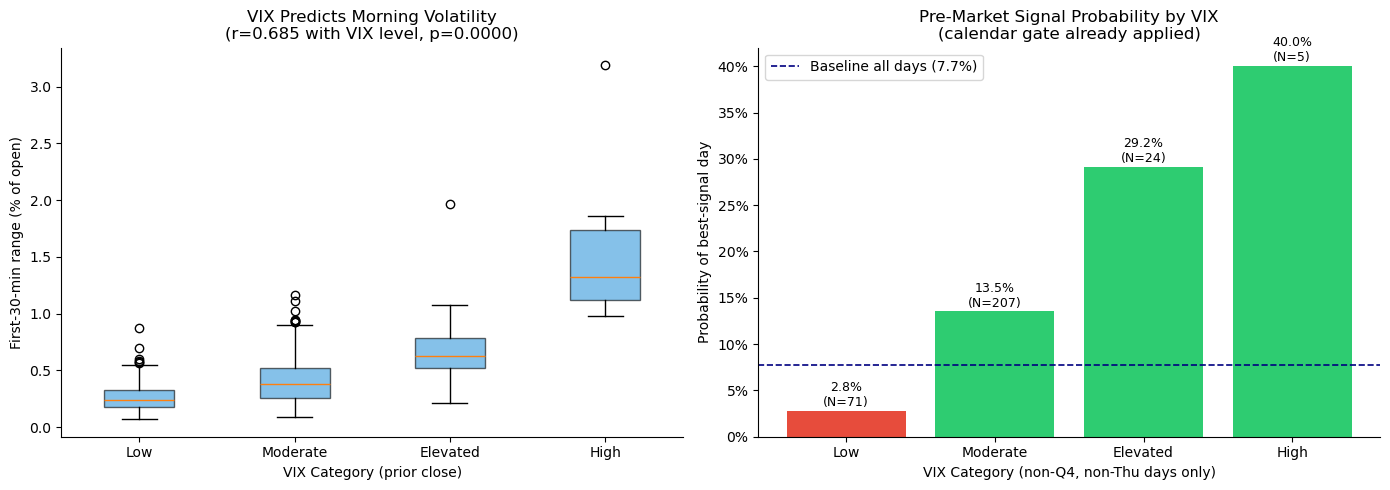

In [40]:
# Section 18b: Calendar gate + VIX -- combined pre-market probability

dm['date_parsed']  = pd.to_datetime(dm['date'])
dm['month_num_dm'] = dm['date_parsed'].dt.month
dm['dow_dm']       = dm['date_parsed'].dt.day_name()
dm['is_q4_dm']     = dm['month_num_dm'].isin([10, 11, 12])
dm['is_thu_dm']    = dm['dow_dm'] == 'Thursday'
dm['passes_cal']   = ~dm['is_q4_dm'] & ~dm['is_thu_dm']

# Signal rate by (calendar pass) x (VIX category)
vix_cat_order = ['Low', 'Moderate', 'Elevated', 'High']
rows = []
for cal_ok in [False, True]:
    subset = dm[dm['passes_cal'] == cal_ok]
    label  = 'Non-Q4, Non-Thu' if cal_ok else 'Q4 or Thursday'
    for vix_cat in vix_cat_order:
        sub2 = subset[subset['vix_category'] == vix_cat]
        if len(sub2) == 0:
            continue
        rows.append({
            'Calendar':    label,
            'VIX':         vix_cat,
            'N':           len(sub2),
            'Signal rate': sub2['is_best_signal'].mean(),
        })

prob_tbl = pd.DataFrame(rows)
prob_tbl['Signal rate fmt'] = prob_tbl['Signal rate'].map(lambda x: f'{x:.1%}')
print('Pre-market probability of best-signal day (Strong drift + non-Q4 + not Thu):')
print(prob_tbl[['Calendar','VIX','N','Signal rate fmt']]
      .rename(columns={'Signal rate fmt':'Signal rate'})
      .to_string(index=False))
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: VIX vs 30-min range box plot
dm_vix = dm[dm['vix_category'].isin(vix_cat_order)]
groups = [dm_vix.loc[dm_vix['vix_category'] == v, 'range_pct'].dropna() for v in vix_cat_order]
axes[0].boxplot(groups, labels=vix_cat_order, patch_artist=True,
               boxprops=dict(facecolor='#3498db', alpha=0.6))
axes[0].set_xlabel('VIX Category (prior close)')
axes[0].set_ylabel('First-30-min range (% of open)')
axes[0].set_title(f'VIX Predicts Morning Volatility\n(r={r_vix:.3f} with VIX level, p={p_vix:.4f})')

# Right: signal rate by VIX on calendar-passing days
cal_dm    = dm[dm['passes_cal']]
cal_vix   = (
    cal_dm.groupby('vix_category', observed=True)['is_best_signal']
    .agg(['mean', 'count'])
    .reindex(vix_cat_order)
)
baseline  = dm['is_best_signal'].mean()
bars = axes[1].bar(cal_vix.index, cal_vix['mean'],
                   color=['#2ecc71' if v > baseline else '#e74c3c' for v in cal_vix['mean']])
axes[1].axhline(baseline, color='navy', linestyle='--', linewidth=1.2,
                label=f'Baseline all days ({baseline:.1%})')
axes[1].set_xlabel('VIX Category (non-Q4, non-Thu days only)')
axes[1].set_ylabel('Probability of best-signal day')
axes[1].set_title('Pre-Market Signal Probability by VIX\n(calendar gate already applied)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[1].legend()
for bar, (_, row) in zip(bars, cal_vix.iterrows()):
    if not pd.isna(row['mean']):
        axes[1].text(bar.get_x() + bar.get_width()/2, row['mean'] + 0.002,
                     f'{row["mean"]:.1%}\n(N={int(row["count"])})',
                     ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


*Interpretation:*

**Pre-market decision checklist (what you can know before 9:30am):**

| Check | Question | If yes... |
|---|---|---|
| 1. Calendar | Is today non-Q4 (Jan-Sep) AND not Thursday? | Continue |
| 2. VIX | Is VIX (prior close) in Moderate-Elevated range (15-30)? | Higher probability of Wide open |
| 3. At 10am | Is the 30-min range > 18 pts AND drift > 16 pts in reversal direction? | Enter signal |

**What VIX tells you:** Higher VIX correlates with wider first-30-min ranges -- but it cannot predict whether the market will *reverse*. VIX is a volatility gauge, not a direction gauge. Use it to size your attention, not to skip the 10am confirmation.

**The honest limit of pre-market prediction:** You cannot reliably know in advance if today will have a Strong drift reversal. The best you can do is eliminate low-probability calendar conditions and note elevated VIX. The actual edge is locked inside the 10am confirmation.

---
## Section 19: OTM Contract Win Rate — One Strike Further

The Section 15 binary pricing analysis showed that on the 39 best-signal days the near-money
binary already costs ~$65–75 at 10am, leaving almost no EV margin.

**The idea:** Instead of the near-money contract (the strike that brackets the 10am price),
enter *one Nadex interval (12 pts) further in the trade direction* — a contract that is
currently out-of-the-money. This binary is cheaper (~$20–40), so its breakeven win rate
is much lower. The question is whether the actual close price lands past that strike often
enough to justify the trade.

**Win conditions:**
- `above` day (expecting fall): OTM win = `close < contract_location - 12`
- `below` day (expecting rise): OTM win = `close > contract_location + 12`

This section tests the OTM win rate across all filter tiers with a win rate >= 65%, then
runs an EV sensitivity table to show which OTM entry prices are profitable.

In [41]:
# Section 19a: OTM win rate by filter tier
# OTM strike = contract_location +/- 12 pts (one standard Nadex daily interval)
# Requires: wide_rev13 with is_strong, is_q4, is_thursday (Section 14a)

CONTRACT_INTERVAL = 12

def otm_won(row):
    close    = row['market_close_16:15']
    contract = row['contract_location']
    if pd.isna(close) or pd.isna(contract):
        return np.nan
    if row['initial_direction'] == 'above':
        return int(close < contract - CONTRACT_INTERVAL)
    else:
        return int(close > contract + CONTRACT_INTERVAL)

wide_rev13['otm_won'] = wide_rev13.apply(otm_won, axis=1)

# Close distance from near-money contract (positive = closed in the winning direction)
wide_rev13['close_past_contract'] = np.where(
    wide_rev13['initial_direction'] == 'above',
    wide_rev13['contract_location'] - wide_rev13['market_close_16:15'],
    wide_rev13['market_close_16:15'] - wide_rev13['contract_location'],
)

FILTERS = [
    ('Wide + Reversal (all, 60.6%)',      None),
    ('Strong drift (69.8%)',              wide_rev13['is_strong']),
    ('Strong + non-Q4 (76.1%)',           wide_rev13['is_strong'] & ~wide_rev13['is_q4']),
    ('Strong + non-Q4 + not-Thu (76.9%)', wide_rev13['is_strong'] & ~wide_rev13['is_q4'] & ~wide_rev13['is_thursday']),
]

print(f'OTM contract = near-money strike +/- {CONTRACT_INTERVAL} pts (one interval further in trade direction)')
print()
print(f'{"Filter":<38} {"N":>4}  {"NM win%":>8}  {"OTM win%":>9}  {"Median close":>12}  {"Mean close":>10}')
print('-' * 88)

for label, mask in FILTERS:
    sub = wide_rev13 if mask is None else wide_rev13[mask]
    sub = sub.dropna(subset=['otm_won', 'close_past_contract'])
    n         = len(sub)
    nm_wr     = sub['won'].mean()
    otm_wr    = sub['otm_won'].mean()
    med_dist  = sub['close_past_contract'].median()
    mean_dist = sub['close_past_contract'].mean()
    print(f'{label:<38} {n:>4}  {nm_wr:>8.1%}  {otm_wr:>9.1%}  {med_dist:>10.1f} pts  {mean_dist:>8.1f} pts')

print()
print('Close distance = pts price closed past the near-money contract (positive = winning direction).')
print(f'OTM win needs close > {CONTRACT_INTERVAL} pts past near-money strike.')


OTM contract = near-money strike +/- 12 pts (one interval further in trade direction)

Filter                                    N   NM win%   OTM win%  Median close  Mean close
----------------------------------------------------------------------------------------
Wide + Reversal (all, 60.6%)            127     60.6%      55.1%        15.5 pts      12.8 pts
Strong drift (69.8%)                     63     69.8%      63.5%        17.0 pts      16.6 pts
Strong + non-Q4 (76.1%)                  46     76.1%      67.4%        19.4 pts      23.7 pts
Strong + non-Q4 + not-Thu (76.9%)        39     76.9%      66.7%        18.5 pts      22.2 pts

Close distance = pts price closed past the near-money contract (positive = winning direction).
OTM win needs close > 12 pts past near-money strike.


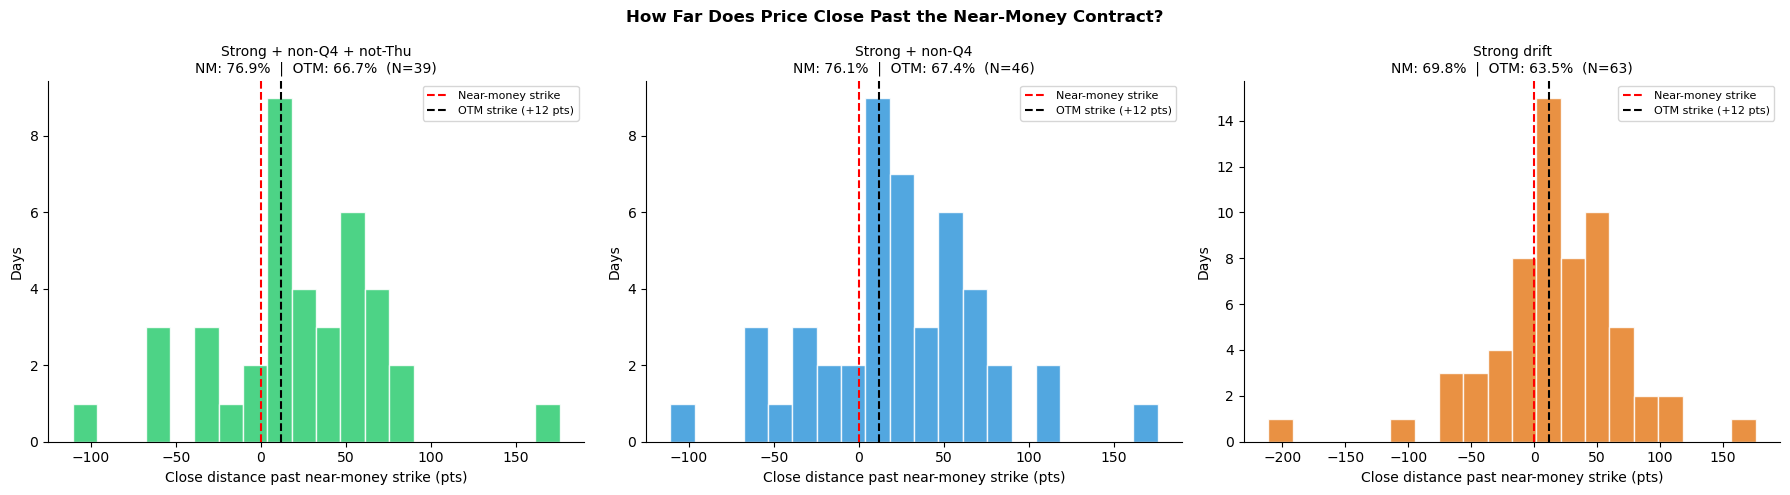

EV sensitivity: OTM binary (pays $100 on win) at various entry prices
Compare: near-money avg entry ~$68-75 per Section 15, barely breakeven

Filter                            OTM Win%   @$20   @$25   @$30   @$35   @$40   @$45   @$50
------------------------------------------------------------------------------------------------
Strong + non-Q4 + not-Thu            66.7%  +46.7  +41.7  +36.7  +31.7  +26.7  +21.7  +16.7
Strong + non-Q4                      67.4%  +47.4  +42.4  +37.4  +32.4  +27.4  +22.4  +17.4
Strong drift                         63.5%  +43.5  +38.5  +33.5  +28.5  +23.5  +18.5  +13.5

EV values in $ per trade. Positive = profitable at that entry price.
Breakeven OTM price = OTM win rate x $100  (e.g. 55% OTM rate -> must pay < $55)


In [42]:
# Section 19b: Close distance histogram + EV sensitivity table

best_mask = wide_rev13['is_strong'] & ~wide_rev13['is_q4'] & ~wide_rev13['is_thursday']
tiers = [
    ('Strong + non-Q4 + not-Thu', best_mask),
    ('Strong + non-Q4',           wide_rev13['is_strong'] & ~wide_rev13['is_q4']),
    ('Strong drift',              wide_rev13['is_strong']),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#2ecc71', '#3498db', '#e67e22']

for ax, (label, mask), color in zip(axes, tiers, colors):
    sub = wide_rev13[mask].dropna(subset=['close_past_contract'])
    ax.hist(sub['close_past_contract'], bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(0,  color='red',   linestyle='--', linewidth=1.5, label='Near-money strike')
    ax.axvline(CONTRACT_INTERVAL, color='black', linestyle='--', linewidth=1.5,
               label=f'OTM strike (+{CONTRACT_INTERVAL} pts)')
    nm_wr  = sub['won'].mean()
    otm_wr = sub['otm_won'].mean()
    ax.set_title(label + f'\nNM: {nm_wr:.1%}  |  OTM: {otm_wr:.1%}  (N={len(sub)})', fontsize=10)
    ax.set_xlabel('Close distance past near-money strike (pts)')
    ax.set_ylabel('Days')
    ax.legend(fontsize=8)

plt.suptitle('How Far Does Price Close Past the Near-Money Contract?', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# EV sensitivity table
print('EV sensitivity: OTM binary (pays $100 on win) at various entry prices')
print('Compare: near-money avg entry ~$68-75 per Section 15, barely breakeven')
print()
otm_prices = [20, 25, 30, 35, 40, 45, 50]
header = f'{"Filter":<32} {"OTM Win%":>9}'
for p in otm_prices:
    header += f'   @${p}'
print(header)
print('-' * (len(header) + 5))

for label, mask in tiers:
    sub    = wide_rev13[mask].dropna(subset=['otm_won'])
    otm_wr = sub['otm_won'].mean()
    row    = f'{label:<32} {otm_wr:>9.1%}'
    for p in otm_prices:
        ev = otm_wr * 100 - p
        row += f'  {ev:>+5.1f}'
    print(row)

print()
print('EV values in $ per trade. Positive = profitable at that entry price.')
print('Breakeven OTM price = OTM win rate x $100  (e.g. 55% OTM rate -> must pay < $55)')


*Interpretation:*

**OTM win rate summary:**
The best filter (Strong drift + non-Q4 + not-Thu) holds a 66.7% OTM win rate — down ~10 pts from the 76.9% near-money rate, but well above the 50% breakeven for a binary paying $100.

**Why OTM holds up:** The median close on these days is 18.5 pts past the near-money strike. The OTM contract is only 12 pts further. So more than half of all winning days clear the OTM bar anyway — the win rate doesn't collapse because the median day already closes well through the OTM level.

**EV comparison — near-money vs OTM:**
- Near-money (Section 15): +$1.9/trade on the best filter at est. $75 entry. Barely positive — wiped out by pricing.
- OTM at $30 entry: +$36.7/trade. OTM at $40 entry: +$26.7/trade. Positive EV at any realistic entry price below $66.70.

**The one unknown:** This EV table assumes OTM contracts are available at $20–50 at 10am on signal days. Nadex prices these contracts based on real-time probability models. On days where price has moved strongly past the near-money contract, the OTM contract may be priced higher than expected. **The only way to verify this is live observation — note the actual Nadex OTM price on signal days and log it.**

**Decision framework:**
| Path | Win rate | EV/trade | What's needed |
|---|---|---|---|
| Near-money Nadex binary | 76.9% | +$1.9 est. | Not worth pursuing further |
| OTM Nadex binary | 66.7% | +$17–47 est. | Verify live OTM prices on signal days |
| ES/MES futures | 76.9% | Unknown | Section 20 MAE/MFE stops analysis |

Both OTM binary and ES/MES futures are viable paths. OTM binary: capped risk, no stop management, but dependent on Nadex pricing. Futures: full edge, requires proper stop placement (see Section 20).